### Polymarket

In [2]:
%run eda_starter_template.py


[Memory] Initial memory usage: 264.94 MB

Loading Bitcoin data from /Users/mig/Documents/LSE/Capstone Project/lse-bitcoin-analytics-capstone-template/data/Coin Metrics/coinmetrics_btc.csv...
[Memory] Before loading Bitcoin data: 264.94 MB
[Memory] After loading Bitcoin data: 268.77 MB (Δ 3.83 MB)
Error loading Bitcoin data: No such file or directory (os error 2): ...ne Project/lse-bitcoin-analytics-capstone-template/data/Coin Metrics/coinmetrics_btc.csv (set POLARS_VERBOSE=1 to see full path)

This error occurred with the following context stack:
	[1] 'csv scan'
	[2] 'with_columns'
	[3] 'sink'

Loading Polymarket data from /Users/mig/Documents/LSE/Capstone Project/lse-bitcoin-analytics-capstone-template/data/Polymarket...
[Memory] Before loading Polymarket data: 268.78 MB
[Memory] After loading Polymarket data: 268.78 MB (Δ 0.00 MB)

[Memory] Final memory usage: 268.78 MB (Total Δ: 3.84 MB)

EDA Layout Complete. Check the 'plots' directory for visualizations.


In [3]:
# edit your directory
%run '/Users/mig/Documents/LSE/Capstone Project/lse-bitcoin-analytics-capstone-template/data/download_data.py'

--- Downloading Capstone Data ---


Retrieving folder contents


Retrieving folder 1mgd1yrowPdQ0JKtdnKBQYHpvcdyRlXcV Coin Metrics
Processing file 1IUADRKckAZVoFYIJjTt9f_la-CQmnXIN coinmetrics_btc.csv
Processing file 1KVBZIl45-DnY0EzbA6-qFZi7kvu1iH8H coinmetrics_spec.md
Retrieving folder 1f_RjuR2AVTpuJeX6jgeoKcspjUp9_lif Polymarket
Processing file 14v0AUTMO6GwQ4ItLNRI8EuxLXplvCoGt finance_politics_event_stats.parquet
Processing file 1oF4B2zvi21br9a6NFVTwjAB8mfNuLdYx finance_politics_markets.parquet
Processing file 1z4nfPZL04Rkhp82piCvqRFerKBQbrXCh finance_politics_odds_history.parquet
Processing file 1QrWoxsFnfxv7Qs1lR4j2wpTs20MqOLnk finance_politics_summary.parquet
Processing file 1K1DjGkN4fkDMRXqZekS_-vRn-WErRLsz finance_politics_tokens.parquet
Processing file 1GO00RPaS7Q2ncX0fcUHiBLyy4bZR4_Yt finance_politics_trades.parquet
Processing file 1SwimJ6dcwl8TWUR1qKWsC1pzXAb9RHTs polymarket_btc_analytics_schema.md
Retrieving folder 1SvAwcdegMzgPANM4pnuTH_9DbNEyXt8N Trilemma Bitcoin Node
Processing file 1rK39jK7QServY_ETFGKXQmXGLjYcUtER bitcoin_analytics.

Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1IUADRKckAZVoFYIJjTt9f_la-CQmnXIN
To: /Users/mig/Documents/LSE/Capstone Project/lse-bitcoin-analytics-capstone-template/eda/tmp_capstone_data/Coin Metrics/coinmetrics_btc.csv
100%|██████████| 2.42M/2.42M [00:01<00:00, 2.38MB/s]
Downloading...
From: https://drive.google.com/uc?id=1KVBZIl45-DnY0EzbA6-qFZi7kvu1iH8H
To: /Users/mig/Documents/LSE/Capstone Project/lse-bitcoin-analytics-capstone-template/eda/tmp_capstone_data/Coin Metrics/coinmetrics_spec.md
100%|██████████| 4.85k/4.85k [00:00<00:00, 701kB/s]
Downloading...
From: https://drive.google.com/uc?id=14v0AUTMO6GwQ4ItLNRI8EuxLXplvCoGt
To: /Users/mig/Documents/LSE/Capstone Project/lse-bitcoin-analytics-capstone-template/eda/tmp_capstone_data/Polymarket/finance_politics_event_stats.parquet
100%|██████████| 1.43M/1.43M [00:00<00:00, 1.80MB/s]
Downloading...
From: https://drive.google


Some files may have been downloaded before the error.
This is often due to Google Drive rate limiting.
Continuing with any successfully downloaded files...

Organizing files...
  Keeping: Coin Metrics/coinmetrics_btc.csv
  Keeping: Coin Metrics/coinmetrics_spec.md
  Keeping: Polymarket/finance_politics_markets.parquet
  Keeping: Polymarket/finance_politics_event_stats.parquet

Successfully organized 4 file(s).
--- Finished downloading ---

Data download and organization complete.


In [4]:
import os
import pandas as pd

COINMETRICS_PATH = '/Users/mig/Documents/LSE/Capstone Project/lse-bitcoin-analytics-capstone-template/eda/data/Coin Metrics/coinmetrics_btc.csv'
POLYMARKET_DIR = '/Users/mig/Documents/LSE/Capstone Project/lse-bitcoin-analytics-capstone-template/eda/data/Polymarket'

# Load Bitcoin data
btc_df = load_bitcoin_data(COINMETRICS_PATH)

# Debug: Check directory and files
print("\n" + "="*80)
print("POLYMARKET DATA LOADING")
print("="*80)
print(f"\nDirectory: {POLYMARKET_DIR}")
print(f"Directory exists: {os.path.exists(POLYMARKET_DIR)}")

if os.path.exists(POLYMARKET_DIR):
    print("\nFiles in directory:")
    all_files = os.listdir(POLYMARKET_DIR)
    for file in sorted(all_files):
        filepath = os.path.join(POLYMARKET_DIR, file)
        size = os.path.getsize(filepath) / (1024*1024)  # Size in MB
        print(f"  {file:50s} ({size:.2f} MB)")
else:
    print("\n✗ ERROR: Directory does not exist!")

print("\n" + "-"*80)

# Load Polymarket data with DETAILED error messages
poly_data = {}

files_to_load = [
    ('markets', 'finance_politics_markets.parquet'),
    ('odds_history', 'finance_politics_odds_history.parquet'),
    ('summary', 'finance_politics_summary.parquet'),
    ('tokens', 'finance_politics_tokens.parquet'), 
    ('trades', 'finance_politics_trades.parquet'),
    ('event_stats', 'finance_politics_event_stats.parquet')
]

for name, filename in files_to_load:
    filepath = os.path.join(POLYMARKET_DIR, filename)
    
    print(f"\n{name}:")
    print(f"  Looking for: {filename}")
    print(f"  Full path: {filepath}")
    print(f"  File exists: {os.path.exists(filepath)}")
    
    if not os.path.exists(filepath):
        print(f"  ✗ SKIPPED: File not found")
        continue
    
    try:
        poly_data[name] = pd.read_parquet(filepath)
        print(f"  ✓ SUCCESS: Loaded {len(poly_data[name]):,} rows, {len(poly_data[name].columns)} columns")
        print(f"  Columns: {', '.join(poly_data[name].columns[:5].tolist())}{'...' if len(poly_data[name].columns) > 5 else ''}")
        
    except Exception as e:
        print(f"  ✗ ERROR: {type(e).__name__}")
        print(f"  Message: {str(e)}")

# Final summary
print("\n" + "="*80)
print("SUMMARY")
print("="*80)
print(f"Bitcoin data: ✓ {len(btc_df):,} rows")
print(f"Polymarket datasets loaded: {len(poly_data)}/{len(files_to_load)}")

if len(poly_data) > 0:
    for name, df in poly_data.items():
        print(f"  ✓ {name:15s}: {len(df):,} rows")
else:
    print("\n⚠ WARNING: No Polymarket files loaded!")
    print("\nPossible reasons:")
    print("  1. Files have different names than expected")
    print("  2. Files are in a different directory")
    print("  3. Files haven't been downloaded yet")
    print("  4. pyarrow library not installed (run: pip install pyarrow)")

print("="*80)


Loading Bitcoin data from /Users/mig/Documents/LSE/Capstone Project/lse-bitcoin-analytics-capstone-template/eda/data/Coin Metrics/coinmetrics_btc.csv...
[Memory] Before loading Bitcoin data: 296.39 MB
[Memory] After loading Bitcoin data: 312.69 MB (Δ 16.30 MB)
Successfully loaded 6221 rows.

POLYMARKET DATA LOADING

Directory: /Users/mig/Documents/LSE/Capstone Project/lse-bitcoin-analytics-capstone-template/eda/data/Polymarket
Directory exists: True

Files in directory:
  finance_politics_event_stats.parquet               (1.37 MB)
  finance_politics_markets.parquet                   (3.22 MB)
  finance_politics_odds_history.parquet              (16.96 MB)
  finance_politics_summary.parquet                   (4.31 MB)
  finance_politics_tokens.parquet                    (9.87 MB)
  finance_politics_trades.parquet                    (3156.20 MB)
  polymarket_btc_analytics_schema.md                 (0.00 MB)

-------------------------------------------------------------------------------

In [5]:
poly_data

{'markets':       market_id                                           question  \
 0        242851  Will Bongbong Marcos be elected President of t...   
 1        242873  Will Sarah Palin win Alaska's special election...   
 2        242918  Will US student loan payments resume by Electi...   
 3        243183       Will $ETH be above $3,000 on April 20, 2022?   
 4        243192  Will Brian Kemp win the Republican nomination ...   
 ...         ...                                                ...   
 78316    242646  Will the total value locked (TVL) in DeFi be $...   
 78317    242686  2022 Hungarian elections: Will Fidesz win at l...   
 78318    242687  Will the price of wheat close above $1050 on A...   
 78319    242688  Will the Progressive Conservative Party win a ...   
 78320    242690  Will Joe Biden's FiveThirtyEight approval rati...   
 
                                                     slug  \
 0      will-bongbong-marcos-be-elected-president-of-t...   
 1      will-

In [6]:
btc_df

time,AdrActCnt,AdrBalCnt,AssetCompletionTime,AssetEODCompletionTime,BlkCnt,CapMVRVCur,CapMrktCurUSD,CapMrktEstUSD,FeeTotNtv,FlowInExNtv,FlowInExUSD,FlowOutExNtv,FlowOutExUSD,HashRate,IssTotNtv,IssTotUSD,PriceBTC,PriceUSD,ROI1yr,ROI30d,ReferenceRate,ReferenceRateETH,ReferenceRateEUR,ReferenceRateUSD,SplyCur,SplyExNtv,SplyExUSD,SplyExpFut10yr,TxCnt,TxTfrCnt,volume_reported_spot_usd_1d
datetime[μs],i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,f64
2009-01-03 00:00:00,0,0,1614334883,1614334883,0,null,null,null,0.0,0.0,null,0.0,null,null,null,null,1,null,null,null,null,null,null,null,0.0,0.0,null,null,0,0,null
2009-01-04 00:00:00,0,0,1614334883,1614334883,0,null,null,null,0.0,0.0,null,0.0,null,null,null,null,1,null,null,null,null,null,null,null,0.0,0.0,null,null,0,0,null
2009-01-05 00:00:00,0,0,1614334883,1614334883,0,null,null,null,0.0,0.0,null,0.0,null,null,null,null,1,null,null,null,null,null,null,null,0.0,0.0,null,null,0,0,null
2009-01-06 00:00:00,0,0,1614334884,1614334884,0,null,null,null,0.0,0.0,null,0.0,null,null,null,null,1,null,null,null,null,null,null,null,0.0,0.0,null,null,0,0,null
2009-01-07 00:00:00,0,0,1614334885,1614334885,0,null,null,null,0.0,0.0,null,0.0,null,null,null,null,1,null,null,null,null,null,null,null,0.0,0.0,null,null,0,0,null
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2026-01-10 00:00:00,608784,55908713,1768101454,1768101454,162,1.610013,1.8058e12,1.8058e12,2.0853467,25172.379573,2.2757e9,25704.121161,2.3238e9,1.1796e9,506.25,4.5768e7,1,90406.142411,-4.593729,-2.394179,90539.603229,29.348301,77853.756824,90539.603229,1.9974e7,2.4808e6,2.2428e11,2.0826e7,492984,1049925,2.9985e9
2026-01-11 00:00:00,536405,55924280,1768186822,1768186822,122,1.615856,1.8120e12,1.8120e12,1.915416,27810.205536,2.5229e9,24486.469835,2.2213e9,8.8831e8,381.25,3.4586e7,1,90717.206315,-4.11103,0.426869,90406.142411,29.333069,77790.505193,90406.142411,1.9974e7,2.4846e6,2.2539e11,2.0826e7,289219,572262,4.3998e9
2026-01-12 00:00:00,638422,55917951,1768275291,1768275291,142,1.623512,1.8205e12,1.8205e12,2.3225772,26842.012928,2.4464e9,29771.239469,2.7134e9,1.0339e9,443.75,4.0444e7,1,91141.149849,-3.404872,0.99272,90717.206315,29.145653,78047.851052,90717.206315,1.9975e7,2.4821e6,2.2622e11,2.0826e7,405384,845895,1.3448e10


In [7]:
category = poly_data['markets'].groupby('category')
print(category.groups.keys())
category.size()

dict_keys(['', 'Business', 'Coronavirus', 'Coronavirus-', 'Crypto', 'Global Politics', 'Politics', 'Pop-Culture ', 'Tech', 'US-current-affairs', 'Ukraine & Russia'])


category
                      77516
Business                113
Coronavirus               3
Coronavirus-              1
Crypto                  340
Global Politics          56
Politics                  1
Pop-Culture               4
Tech                      2
US-current-affairs      265
Ukraine & Russia         20
dtype: int64

In [8]:
# 1. Define your keyword map
keyword_map = {
    'Crypto': 'bitcoin|eth|solana|crypto|token|airdrop',
    'Politics': 'trump|biden|harris|election|senate|republican|democrat',
    'Ukraine & Russia': 'ukraine|russia|putin|zelensky|kremlin',
    'Pop-Culture': 'oscars|grammy|taylor swift|box office|celebrity',
    'Tech': 'ai|openai|gpt|google|nvidia|meta|apple',
    'Global Politics': 'israel|gaza|iran|china|taiwan|uk|london'
}

# 2. Filter for only the rows where category is blank
blank_mask = (poly_data['markets']['category'] == '') | (poly_data['markets']['category'].isna())

# 3. Loop through the map and update blank categories based on question text
for cat, keywords in keyword_map.items():
    # Only update if the row is currently blank AND the question contains a keyword
    match_mask = blank_mask & poly_data['markets']['question'].str.contains(keywords, case=False, na=False)
    poly_data['markets'].loc[match_mask, 'category'] = cat

# 4. See how many are left blank now
print(poly_data['markets']['category'].value_counts())

category
Crypto                57852
Politics              10909
                       7421
Tech                    766
Global Politics         694
Ukraine & Russia        293
US-current-affairs      265
Business                113
Pop-Culture               4
Coronavirus               3
Coronavirus-              1
Name: count, dtype: int64


### Calculate SPD

In [9]:
btc_pandas_df = btc_df.to_pandas()
btc_pandas_df["spd"] = (1/btc_pandas_df["PriceUSD"])*100_000_000


### Top 10 Volume 

In [10]:
poly_data_markets = poly_data["markets"]
print(poly_data_markets["created_at"].max())
print(poly_data_markets["created_at"].min())
top_1000_volume = poly_data_markets.nlargest(1000, "volume")

2025-12-10 05:32:21
2020-10-02 16:10:01


In [11]:
top_1000_volume

,market_id,question,slug,event_slug,category,volume,active,closed,created_at,end_date
2490,253591,Will Donald Trump win the 2024 US Presidential...,will-donald-trump-win-the-2024-us-presidential...,presidential-election-winner-2024,Politics,1.531479e+09,True,True,2024-01-04 17:33:51,2024-11-05 12:00:00
2496,253597,Will Kamala Harris win the 2024 US Presidentia...,will-kamala-harris-win-the-2024-us-presidentia...,presidential-election-winner-2024,Politics,1.037039e+09,True,True,2024-01-04 17:40:17,2024-11-04 12:00:00
4619,511754,Will Donald Trump be inaugurated?,will-donald-trump-be-inaugurated,who-will-be-inaugurated-as-president,Politics,4.004095e+08,True,True,2024-11-01 20:59:58,2025-01-20 12:00:00
4909,512340,Will Nicolae Ciucă win the 2024 Romanian Presi...,will-nicolae-ciuca-win-the-2024-romanian-presi...,romania-presidential-election,Politics,3.265077e+08,True,True,2024-11-07 23:53:29,2024-12-08 12:00:00
2127,253642,Will any other Republican Politician win the 2...,will-any-other-republican-politician-win-the-2...,presidential-election-winner-2024,Politics,2.416551e+08,True,True,2024-01-06 19:52:35,2024-11-05 00:00:00
...,...,...,...,...,...,...,...,...,...,...
7230,526659,"Will Bitcoin reach $105,000 again by March 31?",will-bitcoin-reach-105000-again-by-march-31,what-price-will-bitcoin-hit-by-march-31,Tech,1.875629e+06,True,True,2025-03-03 19:55:21,2025-03-31 12:00:00
15559,565927,"Bitcoin above $118,000 on July 28?",bitcoin-above-118000-on-july-28,bitcoin-above-118000-on-july-28,Crypto,1.872255e+06,True,True,2025-07-21 12:35:45,2025-07-28 16:00:00
56428,659268,"Will Ethereum dip to $3,000 in November?",will-ethereum-dip-to-3000-in-november-2025,what-price-will-ethereum-hit-in-november-2025,Crypto,1.870700e+06,True,True,2025-11-01 01:10:20,2025-12-01 05:00:00
13900,559655,Will Josh Shapiro win the 2028 Democratic pres...,will-josh-shapiro-win-the-2028-democratic-pres...,democratic-presidential-nominee-2028,Politics,1.870236e+06,True,False,2025-07-03 20:37:01,2028-11-07 00:00:00


In [12]:
poly_data_odds = poly_data["odds_history"]
poly_data_odds

,market_id,token_id,timestamp,price
0,255140,4743579536152330606866939019100172195245171947...,1970-01-20 21:10:04.802,0.0550
1,255140,4743579536152330606866939019100172195245171947...,1970-01-20 21:11:31.203,0.0550
2,255140,4743579536152330606866939019100172195245171947...,1970-01-20 21:12:57.604,0.0550
3,255140,4743579536152330606866939019100172195245171947...,1970-01-20 21:14:24.002,0.0550
4,255140,4743579536152330606866939019100172195245171947...,1970-01-20 21:15:50.403,0.0550
...,...,...,...,...
2143176,897329,1441341842174471672181235644969822857103541674...,1970-01-21 10:55:12.022,0.9595
2143177,897329,1441341842174471672181235644969822857103541674...,1970-01-21 10:56:38.419,0.9595
2143178,897329,1441341842174471672181235644969822857103541674...,1970-01-21 10:58:04.822,0.9640
2143179,897329,1441341842174471672181235644969822857103541674...,1970-01-21 10:59:31.225,0.9640


In [13]:
poly_data_trades = poly_data["trades"]
poly_data_trades

,trade_id,market_id,token_id,timestamp,price,size,side,maker_address,taker_address
0,0x036e539d9361b15d9ebee9bbd1aebf42e45a1e07a9bd...,570360,2148977251641003858655674434239298204418999936...,1970-01-21 09:52:39.845,0.977000,281.054246,BUY,0x27d76669db4321111b08fcc7e1a5bf622b98693c,0xc5d563a36ae78145c45a50134d48a1215220f80a
1,0x8685bb4a3134f9f664ed7e619b8ea693352f94285b34...,570360,2148977251641003858655674434239298204418999936...,1970-01-21 09:52:39.857,0.977000,28.000000,BUY,0x33dcee9b336230ed7460c98bec8ff3115296a539,0xc5d563a36ae78145c45a50134d48a1215220f80a
2,0xab71cfe8f3cb18e629b873b65b84ea386924891e758e...,570360,2148977251641003858655674434239298204418999936...,1970-01-21 09:52:39.871,0.977000,182.000000,BUY,0x87370aa54b8f70fa1c9637f367aadd3156782bff,0xc5d563a36ae78145c45a50134d48a1215220f80a
3,0xfe619b29a0b6aa958cbd565c18f0aedc451139aac0f9...,570360,2148977251641003858655674434239298204418999936...,1970-01-21 09:52:39.889,0.977081,49.000000,BUY,0xa3ad70cf48a2f2b44163e798223c01a2c2536866,0xc5d563a36ae78145c45a50134d48a1215220f80a
4,0x953032bcaecd5bf0007c44acddb0c6c9c80f2c063a55...,570360,2148977251641003858655674434239298204418999936...,1970-01-21 09:52:39.925,0.978000,147.800000,BUY,0x4ee06f42e20ee128db78d42252176bf3a9ce7cce,0xc5d563a36ae78145c45a50134d48a1215220f80a
...,...,...,...,...,...,...,...,...,...
27013719,0x4a86d7efa03d352f6990dfb61bd87f3c31a84c9b57f1...,561985,2652814724933719576712958625055698322914303600...,1970-01-21 10:59:54.319,0.992000,5.413250,BUY,,
27013720,0x6939770889fa51da300bbab08bf1750853103848a59d...,562004,3337233094702386052587063075854913790217057691...,1970-01-21 10:59:54.319,0.990000,23.151500,BUY,,
27013721,0x126f0595e5e8bc7039206ffc20ced52f9db85fa5ec9c...,561973,2782897664868246677877699907621542377776697298...,1970-01-21 10:59:54.319,0.961000,25.005179,BUY,,
27013722,0x4b070936d6916aa985ad7b1dc9d6e5899642172b4003...,561991,8409529381329385248635760260604838650759146033...,1970-01-21 10:59:54.319,0.995000,25.005000,BUY,,


In [14]:
poly_data_trades["date"] = pd.to_datetime(poly_data_trades["timestamp"].astype("int64"), unit="ms").dt.normalize()
print(poly_data_trades["date"].head())

0   2025-11-19
1   2025-11-19
2   2025-11-19
3   2025-11-19
4   2025-11-19
Name: date, dtype: datetime64[ns]


In [15]:

trades_with_questions = poly_data_trades.merge(
    poly_data_markets,
    on="market_id",
    how="inner"
)

In [16]:
daily_odds = (
    trades_with_questions
    .groupby(["market_id", "question", "date"])["price"]
    .mean()
    .reset_index()
    .sort_values(["market_id", "date"])
)

In [17]:
daily_odds

,market_id,question,date,price
0,510319,Trump ends Ukraine war in first 90 days?,2025-04-07,0.032923
1,510319,Trump ends Ukraine war in first 90 days?,2025-04-08,0.027126
2,510319,Trump ends Ukraine war in first 90 days?,2025-04-09,0.025042
3,510319,Trump ends Ukraine war in first 90 days?,2025-04-10,0.022826
4,510319,Trump ends Ukraine war in first 90 days?,2025-04-11,0.023415
...,...,...,...,...
143974,904395,Will Stacy Rogers win the 2026 Kansas Governor...,2025-12-10,0.500000
143975,904740,"Bitcoin Up or Down - December 11, 7PM ET",2025-12-10,0.510000
143976,904899,"Bitcoin Up or Down - December 10, 7:45PM-8:00P...",2025-12-10,0.495496
143977,904934,"Bitcoin Up or Down - December 10, 8:15PM-8:30P...",2025-12-10,0.495000


In [18]:
print(daily_odds["question"].nunique())
print(daily_odds.shape)

36043
(143979, 4)


## Analysis 1
### Step 1 : ACF and PACF plot

**ACF** : $\rho_k = \frac{\sum_{t=k+2}^{n}(x_t-\bar{x})(x_{t-k}-\bar{x})}{\sum_{t=1}^{n}(x_t-\bar{x})^2}$

Pearson correlation between $x_t$ and $x_{t−k}$.

**PACF** : $x_t = \phi_1 x_{t-1}+ \phi_2 x_{t-2} +...+\phi_k x_{t-k} +\epsilon_t$

The PACF at lag k is just the coefficient $\phi_k$ from this regression. Everything before lag k is already accounted for, so $\phi_k$ only captures what lag k contributes on its own.

ACF = "How long does this market remember past information?"<br>
PACF = "How many days do I actually need to look back?"<br>
Stable convergence = "Is this market worth trusting as a signal at all?"



In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.stattools import acf
from scipy import stats

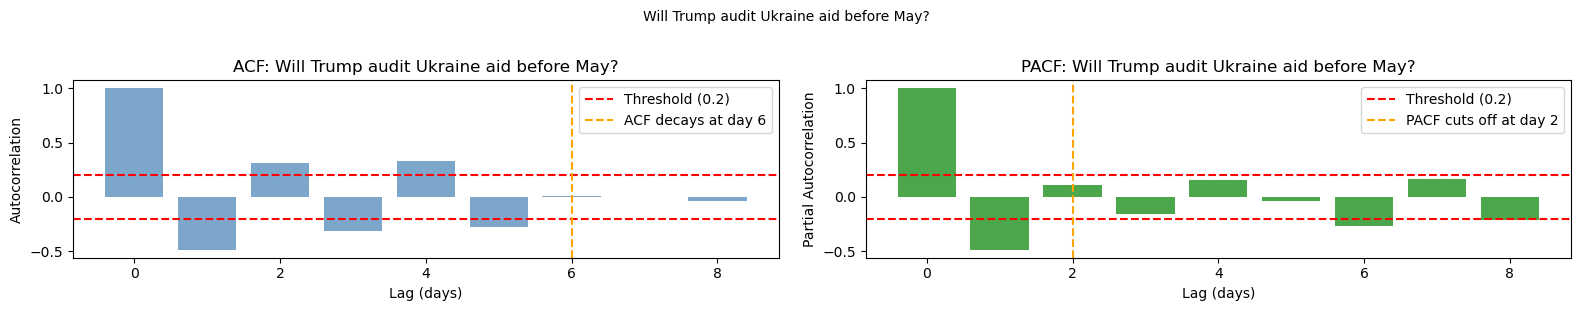

→ ACF signal persists for ~6 days | PACF true lag: 2 days | Will Trump audit Ukraine aid before May?


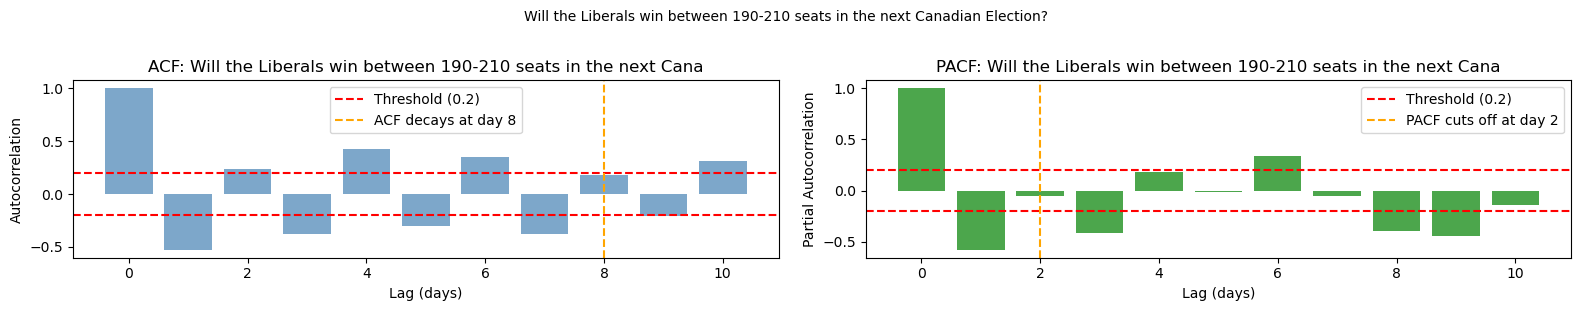

→ ACF signal persists for ~8 days | PACF true lag: 2 days | Will the Liberals win between 190-210 seats in the next Cana


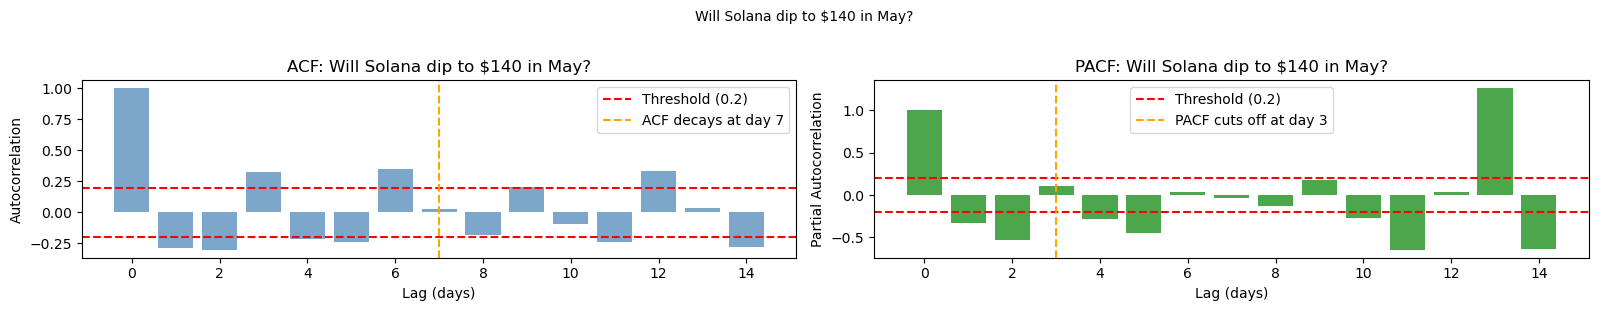

→ ACF signal persists for ~7 days | PACF true lag: 3 days | Will Solana dip to $140 in May?


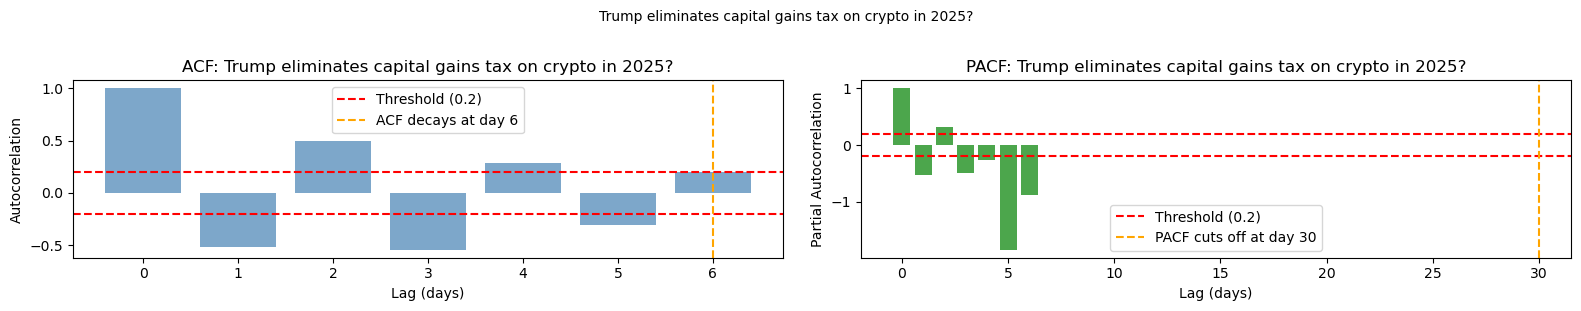

→ ACF signal persists for ~6 days | PACF true lag: 30 days | Trump eliminates capital gains tax on crypto in 2025?


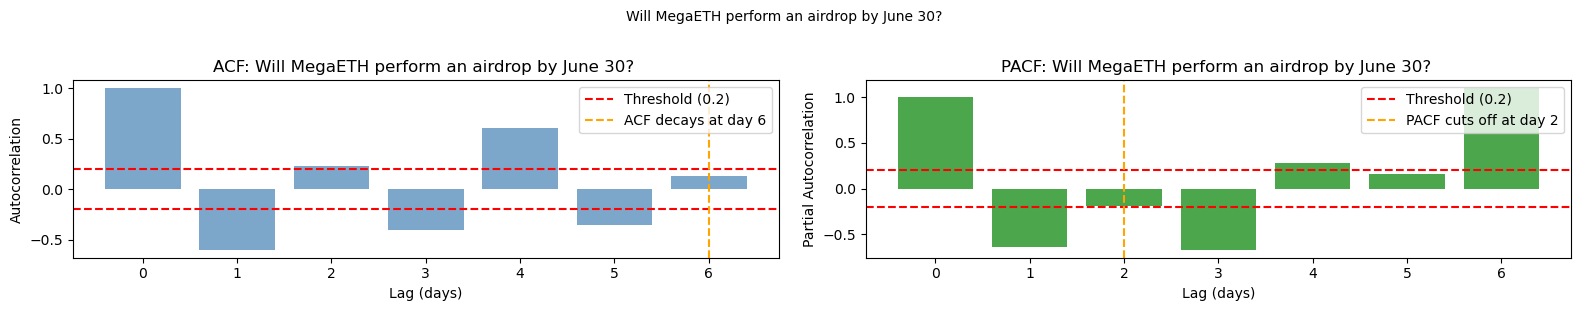

→ ACF signal persists for ~6 days | PACF true lag: 2 days | Will MegaETH perform an airdrop by June 30? 


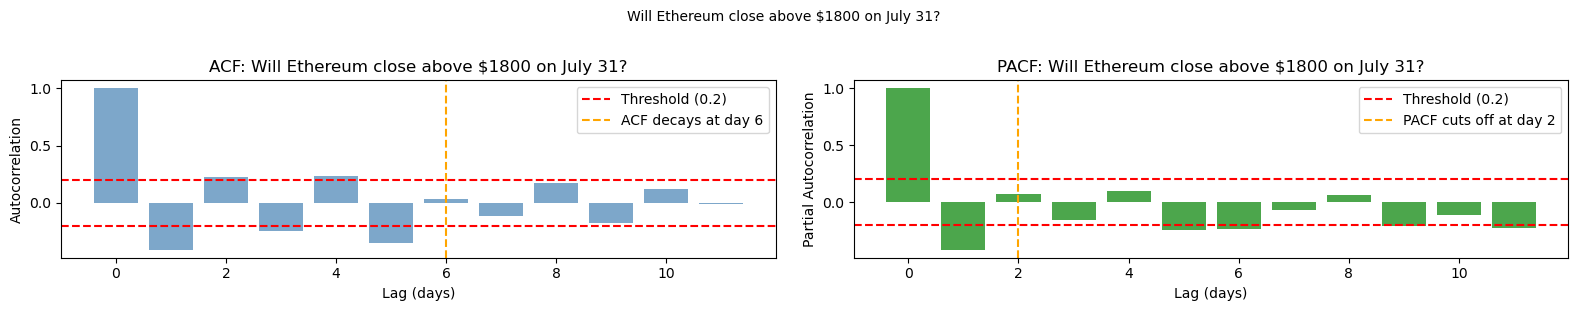

→ ACF signal persists for ~6 days | PACF true lag: 2 days | Will Ethereum close above $1800 on July 31?


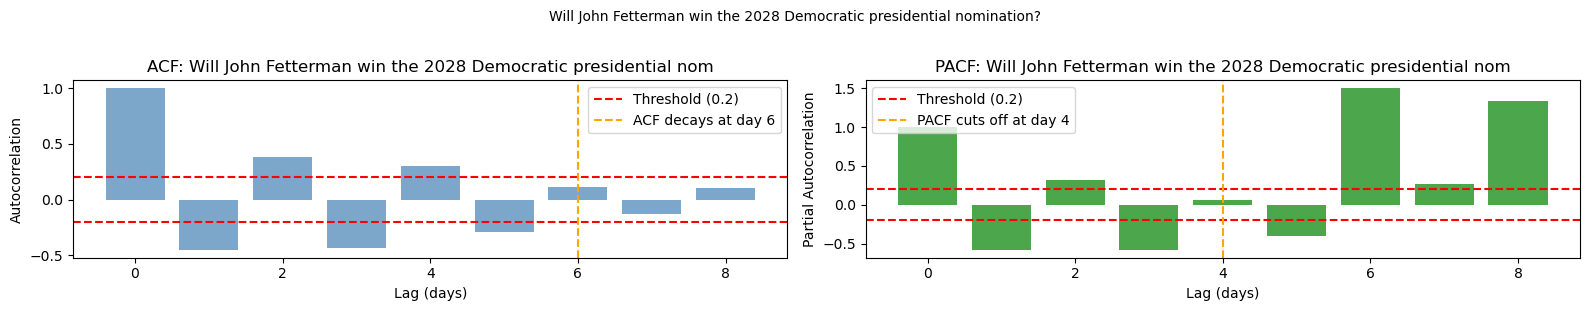

→ ACF signal persists for ~6 days | PACF true lag: 4 days | Will John Fetterman win the 2028 Democratic presidential nom


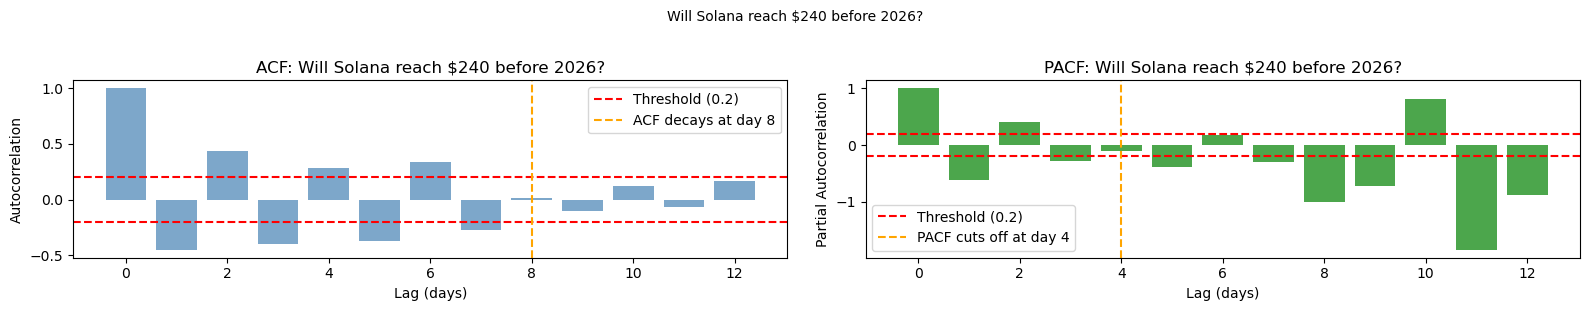

→ ACF signal persists for ~8 days | PACF true lag: 4 days | Will Solana reach $240 before 2026?


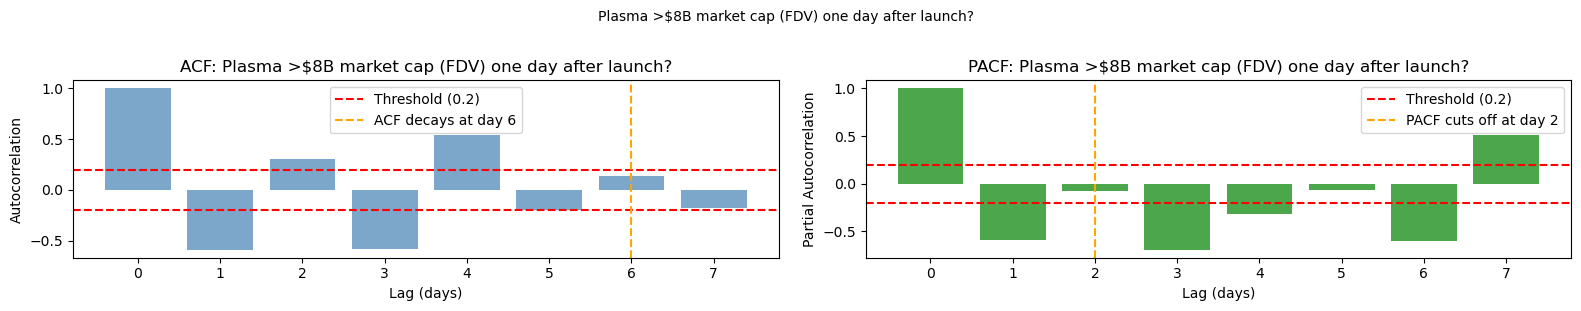

→ ACF signal persists for ~6 days | PACF true lag: 2 days | Plasma >$8B market cap (FDV) one day after launch?


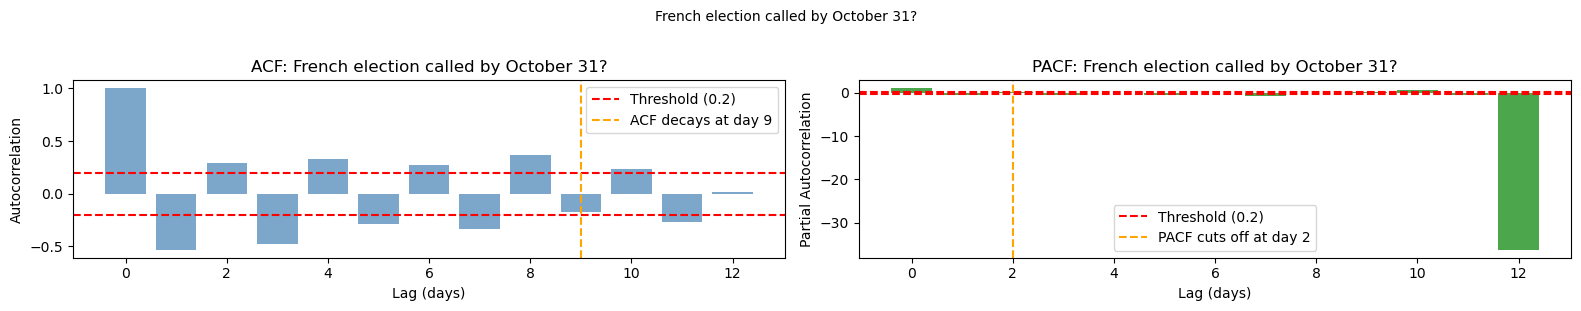

→ ACF signal persists for ~9 days | PACF true lag: 2 days | French election called by October 31?


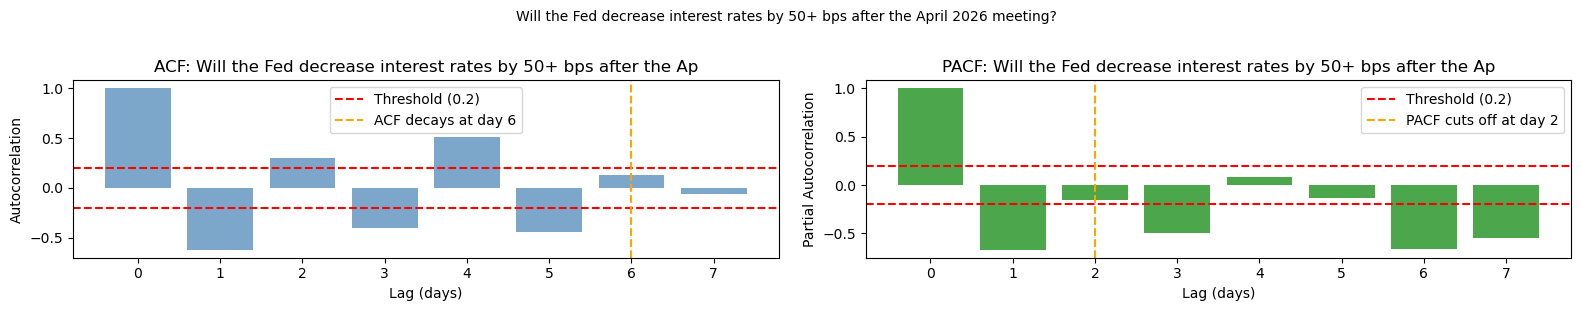

→ ACF signal persists for ~6 days | PACF true lag: 2 days | Will the Fed decrease interest rates by 50+ bps after the Ap


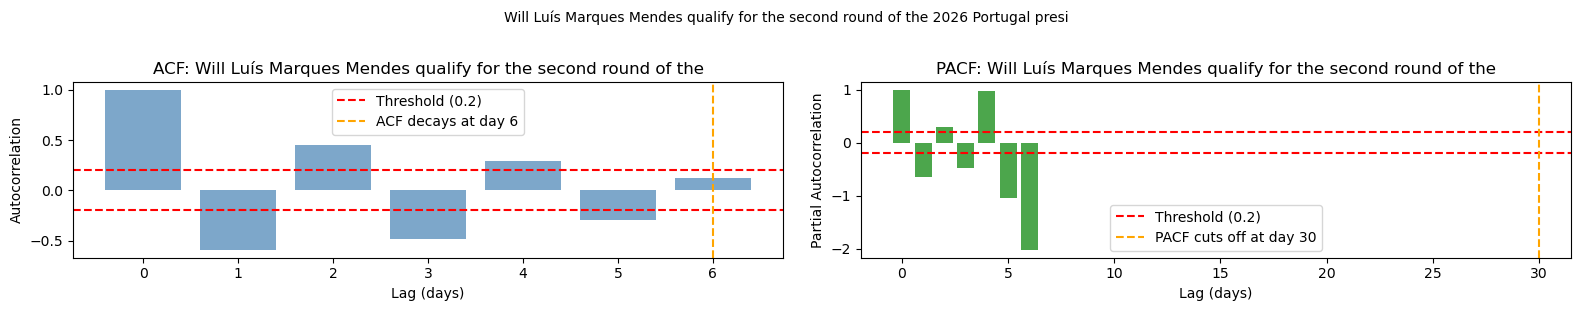

→ ACF signal persists for ~6 days | PACF true lag: 30 days | Will Luís Marques Mendes qualify for the second round of the


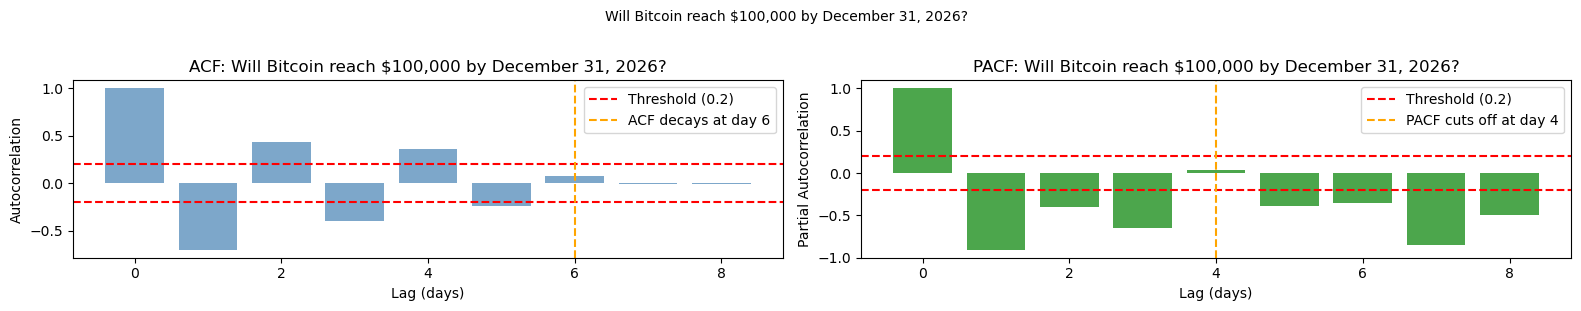

→ ACF signal persists for ~6 days | PACF true lag: 4 days | Will Bitcoin reach $100,000 by December 31, 2026?


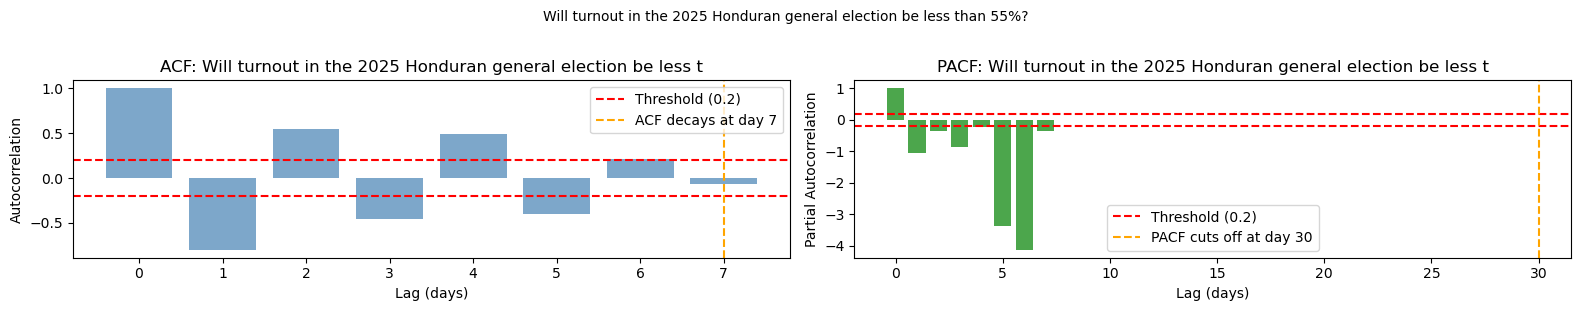

→ ACF signal persists for ~7 days | PACF true lag: 30 days | Will turnout in the 2025 Honduran general election be less t


In [20]:
from statsmodels.tsa.stattools import acf, pacf

FOCUS_MARKETS = daily_odds["question"].unique()

def plot_acf_pacf_for_market(market_name, poly_df, max_lag=30):
    df = poly_df[poly_df["question"] == market_name].copy()
    df_start = df["date"].min()
    df_end = df["date"].max()
    duration = df_end - df_start

    if duration.days < 14:
        return None

    df["odds_change"] = df["price"].diff()
    series = df["odds_change"].dropna()

    if df["price"].std() < 0.05:
        return None

    # PACF requires nlags < 50% of sample size
    safe_lag = min(max_lag, len(series) // 2 - 1)
    if safe_lag < 5:
        return None

    acf_vals = acf(series, nlags=safe_lag, fft=True)
    pacf_vals = pacf(series, nlags=safe_lag, method="ols")

    # ACF decay day
    acf_decay_day = next((i for i, v in enumerate(acf_vals[1:], start=1) if abs(v) < 0.2), max_lag)
    if acf_decay_day == max_lag:
        return None

    # PACF cutoff day (first lag where PACF drops below threshold)
    pacf_cutoff_day = next((i for i, v in enumerate(pacf_vals[1:], start=1) if abs(v) < 0.2), max_lag)

    if acf_decay_day > 5:
        fig, axes = plt.subplots(1, 2, figsize=(16, 3))

        # --- ACF plot ---
        axes[0].bar(range(len(acf_vals)), acf_vals, color="steelblue", alpha=0.7)
        axes[0].axhline(0.2, color="red", linestyle="--", label="Threshold (0.2)")
        axes[0].axhline(-0.2, color="red", linestyle="--")
        axes[0].axvline(acf_decay_day, color="orange", linestyle="--", label=f"ACF decays at day {acf_decay_day}")
        axes[0].set_title(f"ACF: {market_name[:60]}")
        axes[0].set_xlabel("Lag (days)")
        axes[0].set_ylabel("Autocorrelation")
        axes[0].legend()

        # --- PACF plot ---
        axes[1].bar(range(len(pacf_vals)), pacf_vals, color="green", alpha=0.7)
        axes[1].axhline(0.2, color="red", linestyle="--", label="Threshold (0.2)")
        axes[1].axhline(-0.2, color="red", linestyle="--")
        axes[1].axvline(pacf_cutoff_day, color="orange", linestyle="--", label=f"PACF cuts off at day {pacf_cutoff_day}")
        axes[1].set_title(f"PACF: {market_name[:60]}")
        axes[1].set_xlabel("Lag (days)")
        axes[1].set_ylabel("Partial Autocorrelation")
        axes[1].legend()

        plt.suptitle(market_name[:80], fontsize=10, y=1.02)
        plt.tight_layout()

        os.makedirs("acf_plots", exist_ok=True)
        plt.savefig(f"acf_plots/acf_pacf_{market_name[:30].replace(' ', '_')}.png", dpi=150, bbox_inches="tight")
        plt.show()

        print(f"→ ACF signal persists for ~{acf_decay_day} days | PACF true lag: {pacf_cutoff_day} days | {market_name[:60]}")

    return {"acf_decay": acf_decay_day, "pacf_cutoff": pacf_cutoff_day}


signal_persistence = {}
for m in FOCUS_MARKETS:
    result = plot_acf_pacf_for_market(m, daily_odds)
    if result:
        signal_persistence[m] = result

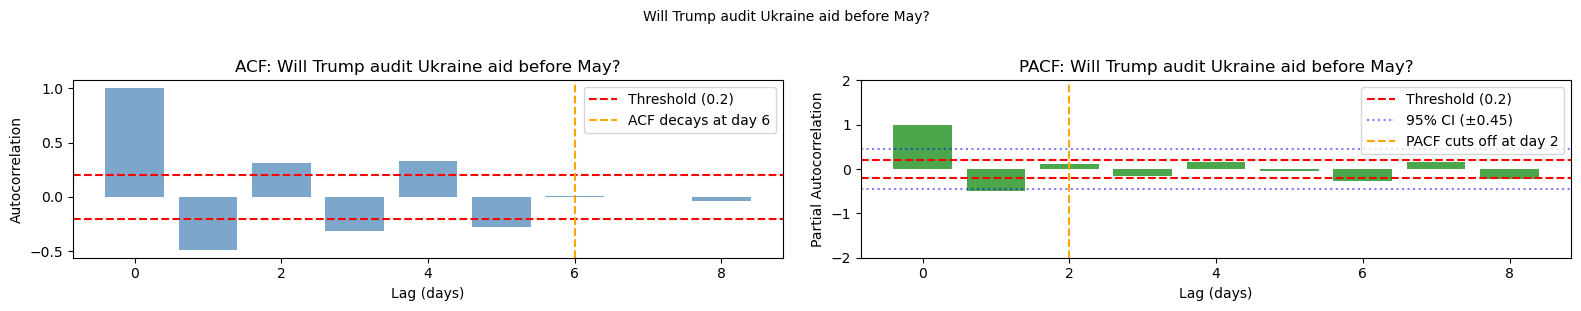

→ ACF signal persists for ~6 days | PACF true lag: 2 days | Will Trump audit Ukraine aid before May?


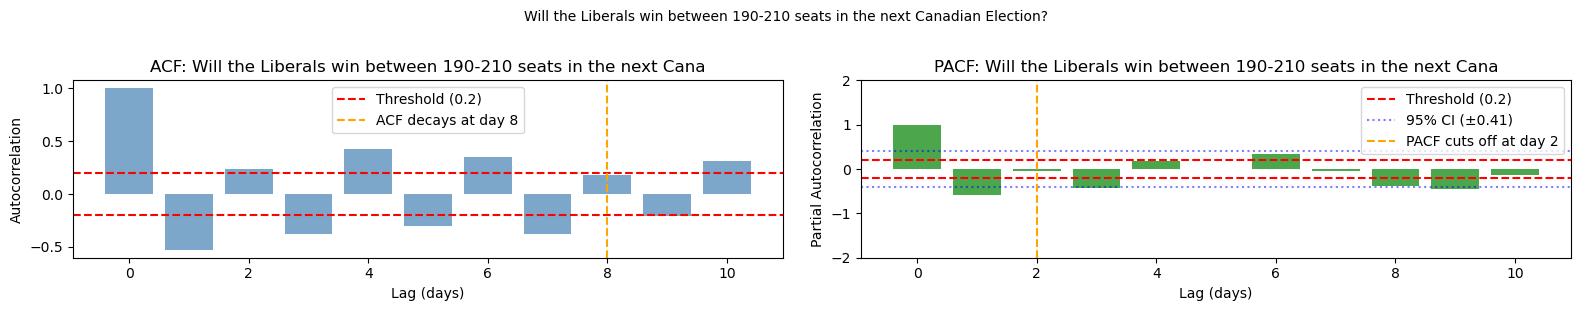

→ ACF signal persists for ~8 days | PACF true lag: 2 days | Will the Liberals win between 190-210 seats in the next Cana


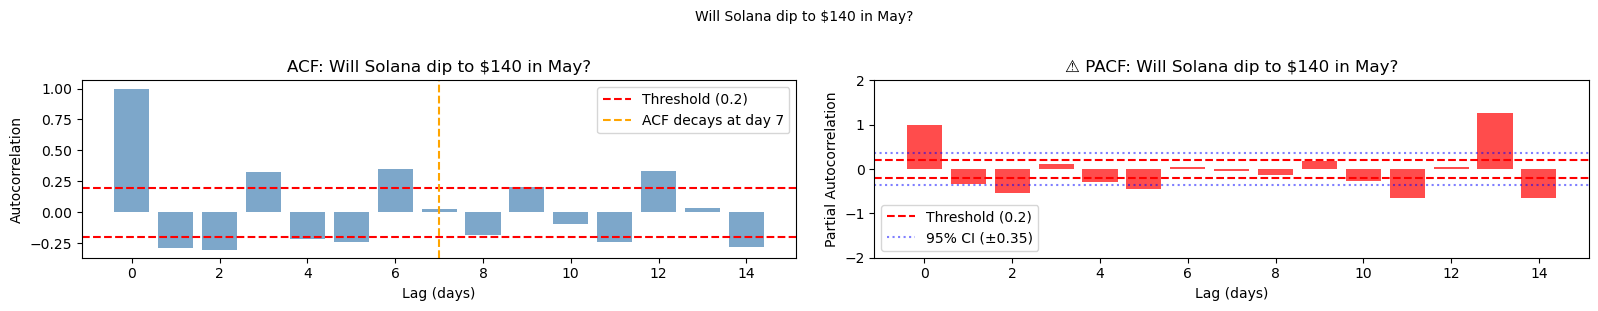

→ ACF signal persists for ~7 days | UNSTABLE | Will Solana dip to $140 in May?


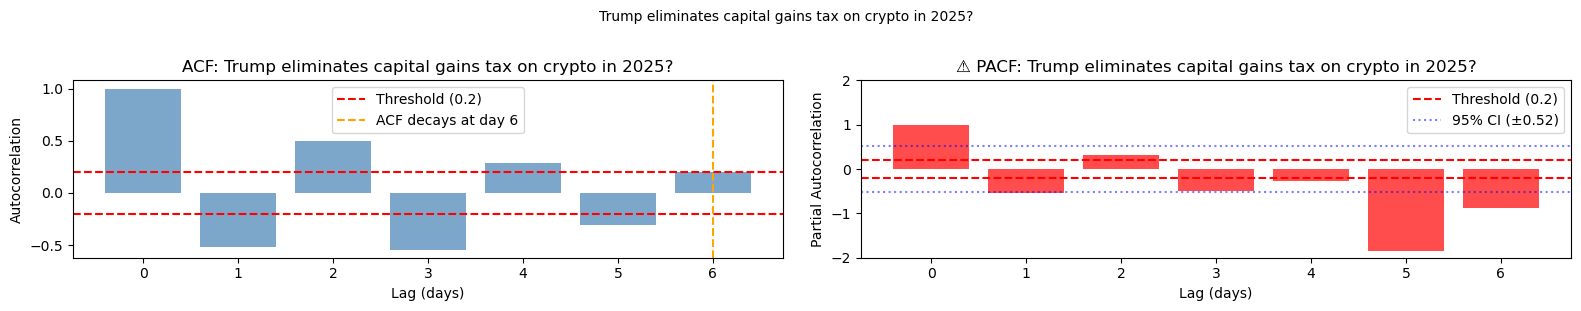

→ ACF signal persists for ~6 days | UNSTABLE | Trump eliminates capital gains tax on crypto in 2025?


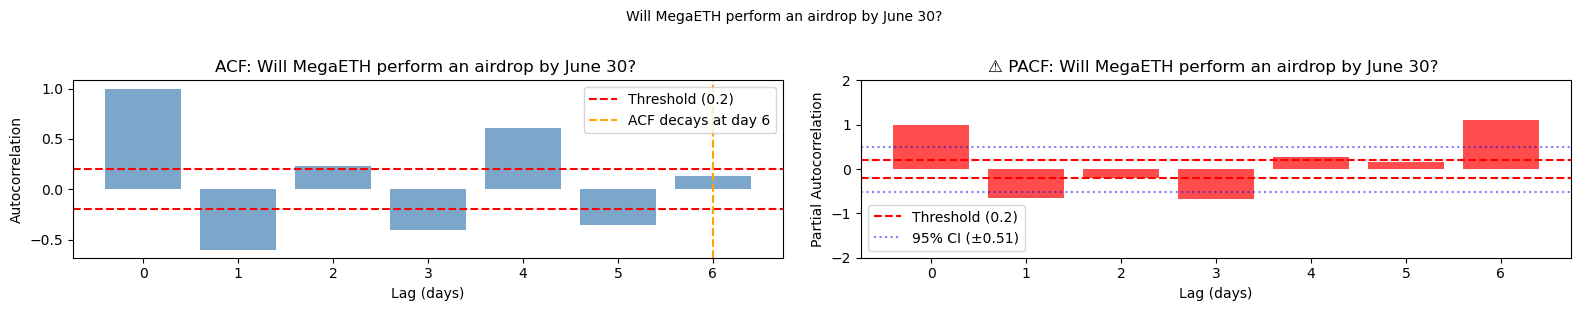

→ ACF signal persists for ~6 days | UNSTABLE | Will MegaETH perform an airdrop by June 30? 


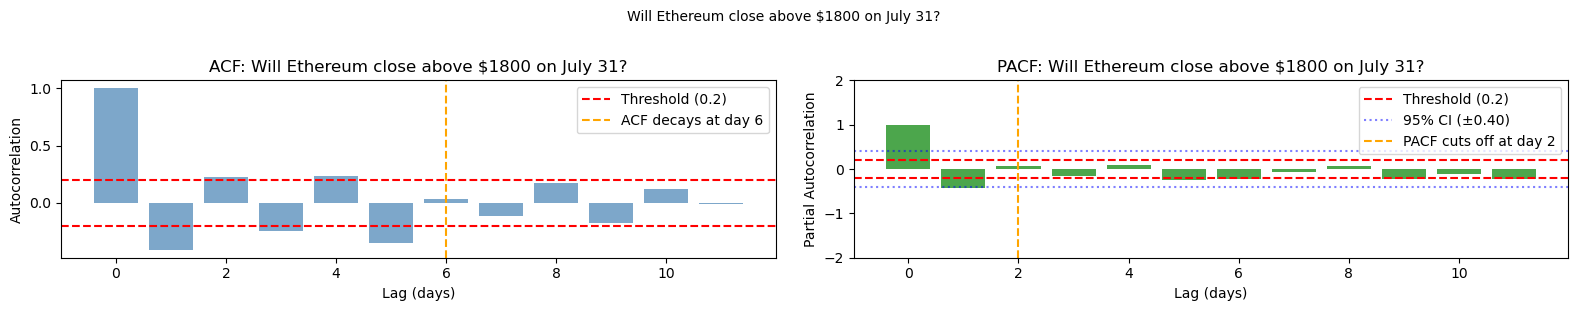

→ ACF signal persists for ~6 days | PACF true lag: 2 days | Will Ethereum close above $1800 on July 31?


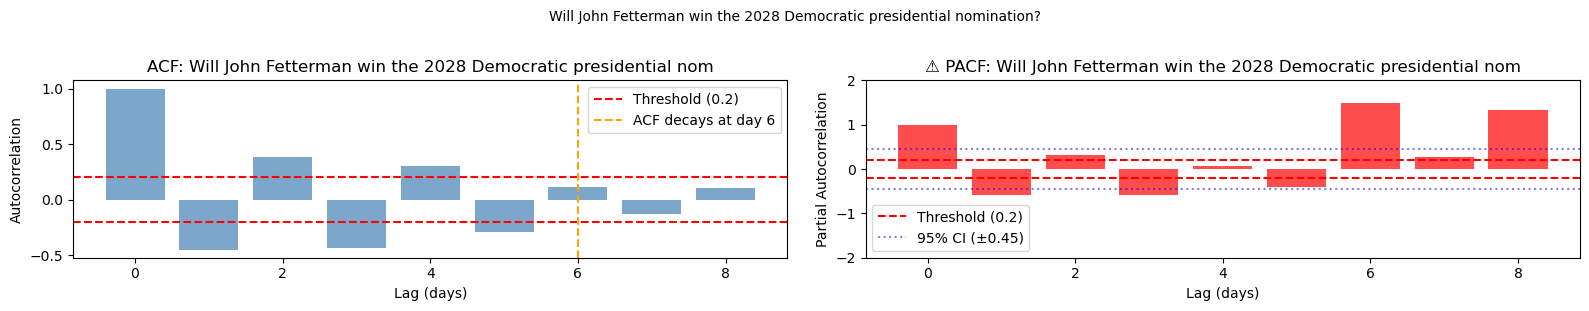

→ ACF signal persists for ~6 days | UNSTABLE | Will John Fetterman win the 2028 Democratic presidential nom


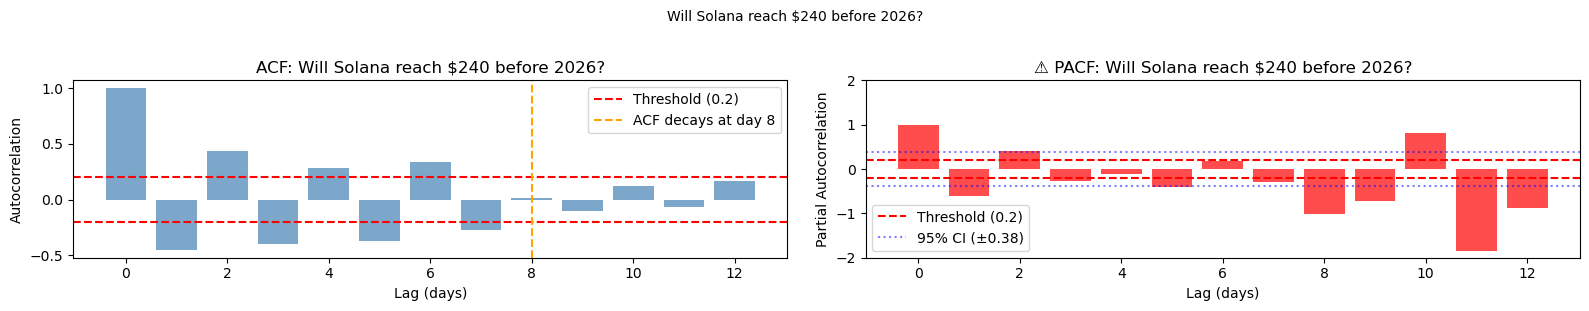

→ ACF signal persists for ~8 days | UNSTABLE | Will Solana reach $240 before 2026?


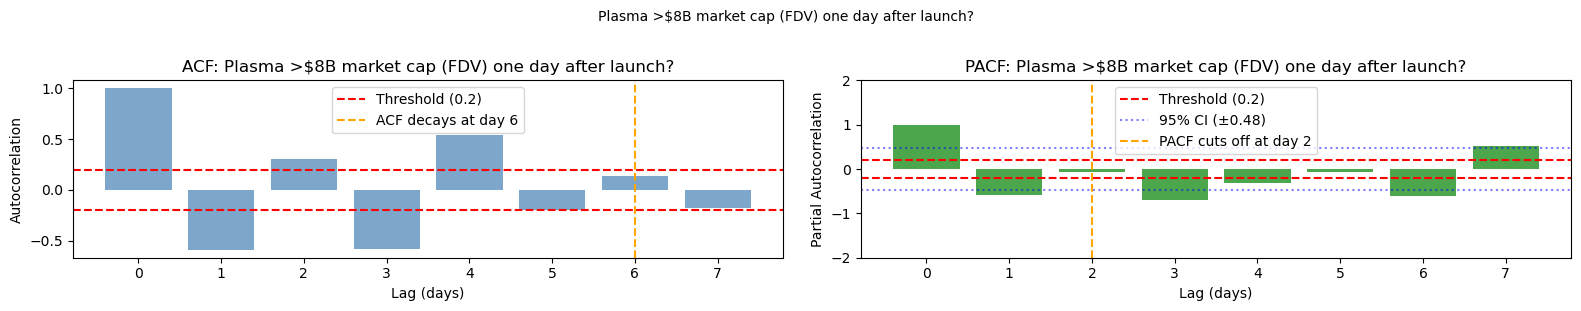

→ ACF signal persists for ~6 days | PACF true lag: 2 days | Plasma >$8B market cap (FDV) one day after launch?


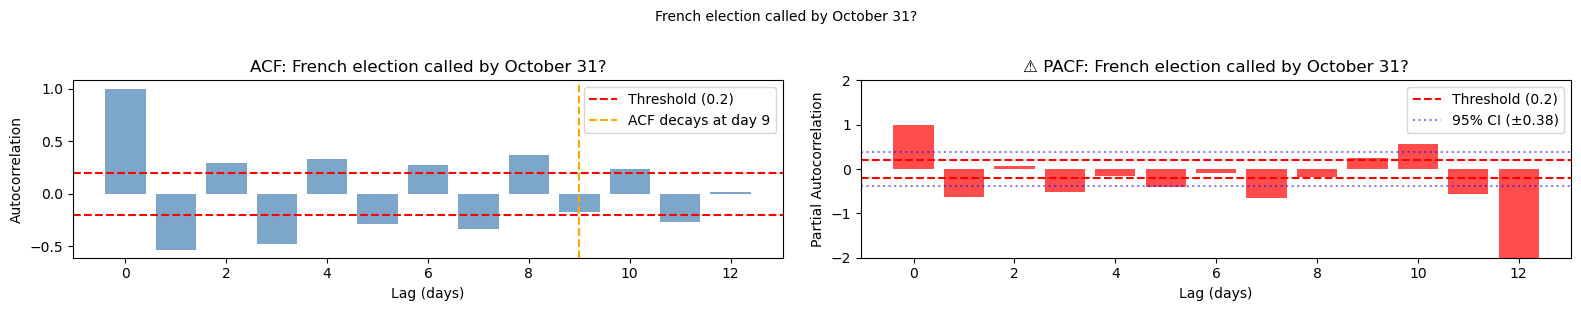

→ ACF signal persists for ~9 days | UNSTABLE | French election called by October 31?


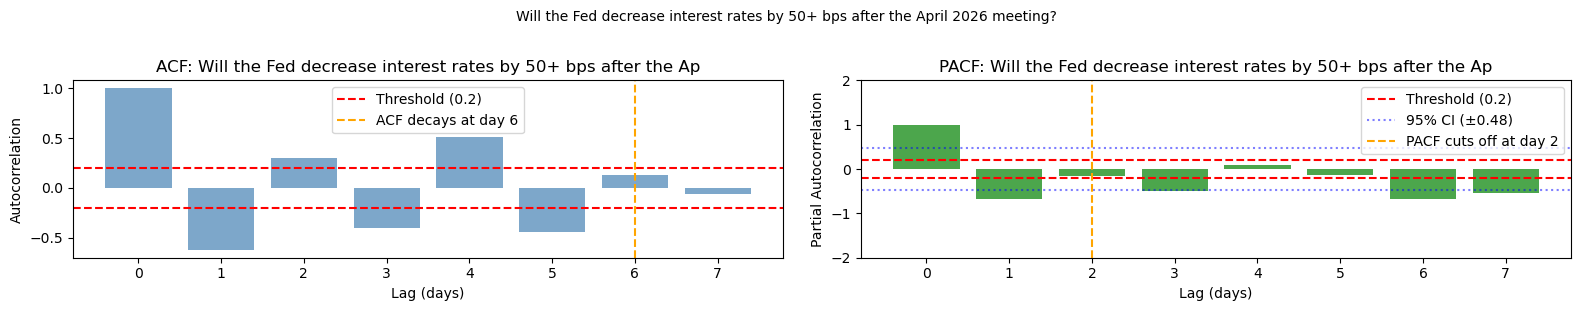

→ ACF signal persists for ~6 days | PACF true lag: 2 days | Will the Fed decrease interest rates by 50+ bps after the Ap


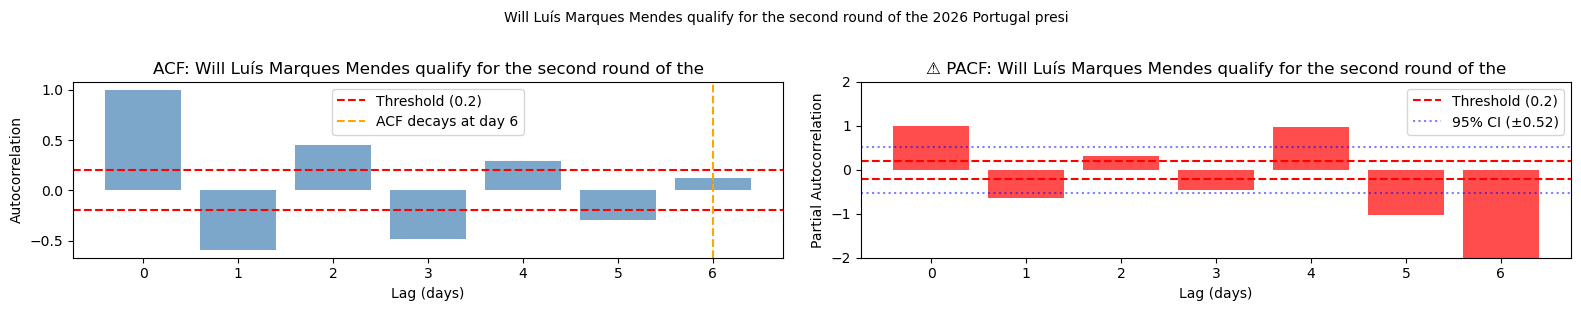

→ ACF signal persists for ~6 days | UNSTABLE | Will Luís Marques Mendes qualify for the second round of the


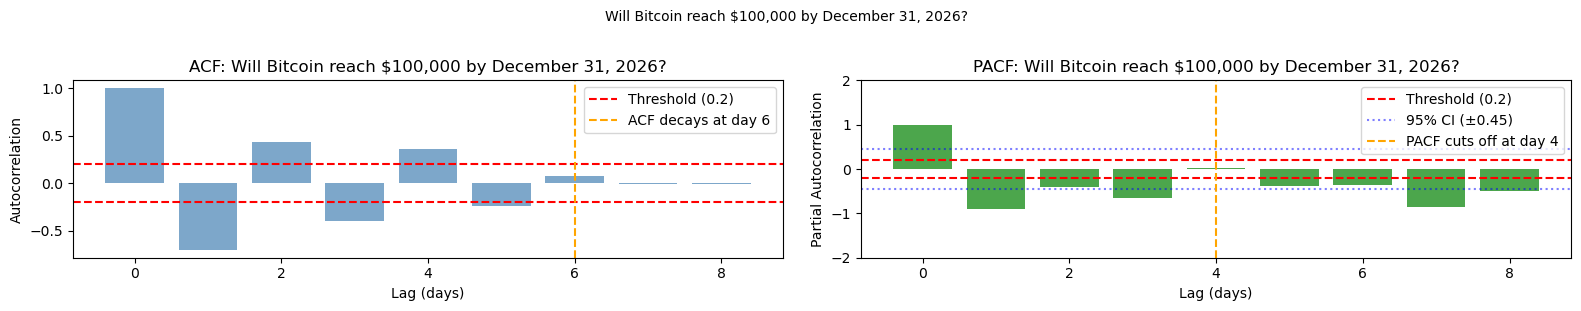

→ ACF signal persists for ~6 days | PACF true lag: 4 days | Will Bitcoin reach $100,000 by December 31, 2026?


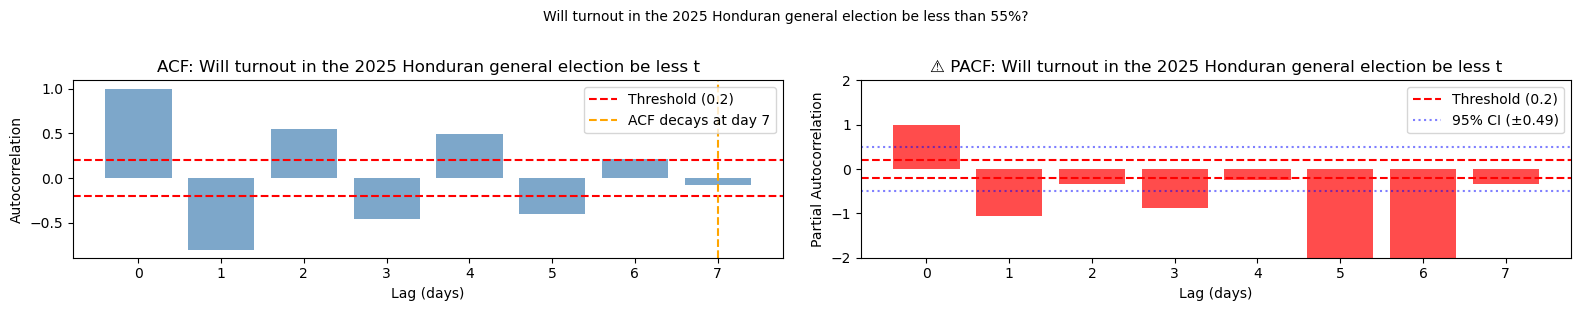

→ ACF signal persists for ~7 days | UNSTABLE | Will turnout in the 2025 Honduran general election be less t

✅ Stable markets:   783
⚠️  Unstable markets: 613

Unstable markets to exclude:
  - Will Karol Nawrocki be the next President of Poland?
  - Will Rafał Trzaskowski be the next President of Poland?
  - Will Trump pardon Roger Ver in his first 100 days?
  - Fed rate hike in 2025?
  - US recession in 2025?
  - Fed emergency rate cut in 2025?
  - Putin out as President of Russia in 2025?
  - Will 2 Fed rate cuts happen in 2025?
  - Will 8+ Fed rate cuts happen in 2025?
  - Will Andrew Cuomo win the Democratic Primary for Mayor of New York City?
  - Will Bitcoin reach $1,000,000 by December 31, 2025?
  - Will Bitcoin reach $250,000 by December 31, 2025?
  - Will Bitcoin reach $200,000 by December 31, 2025?
  - Will Bitcoin reach $150,000 by December 31, 2025?
  - Will Bitcoin reach $110,000 by December 31, 2025?
  - Will Bitcoin dip to $70,000 by December 31, 2025?
  - Will Bitcoin d

In [21]:
from statsmodels.tsa.stattools import acf, pacf

FOCUS_MARKETS = daily_odds["question"].unique()

def plot_acf_pacf_for_market(market_name, poly_df, max_lag=30):
    df = poly_df[poly_df["question"] == market_name].copy()
    df_start = df["date"].min()
    df_end = df["date"].max()
    duration = df_end - df_start

    if duration.days < 14:
        return None

    df["odds_change"] = df["price"].diff()
    series = df["odds_change"].dropna()

    if df["price"].std() < 0.05:
        return None

    # PACF requires nlags < 50% of sample size
    safe_lag = min(max_lag, len(series) // 2 - 1)
    if safe_lag < 5:
        return None

    acf_vals = acf(series, nlags=safe_lag, fft=True)
    pacf_vals = pacf(series, nlags=safe_lag, method="ols")

    # ACF decay day
    acf_decay_day = next((i for i, v in enumerate(acf_vals[1:], start=1) if abs(v) < 0.2), max_lag)
    if acf_decay_day == max_lag:
        return None

    # PACF cutoff day (first lag where PACF drops below threshold)
    pacf_cutoff_day = next((i for i, v in enumerate(pacf_vals[1:], start=1) if abs(v) < 0.2), max_lag)

    # Define is_unstable here so it's always in scope
    is_unstable = any(abs(v) > 1 for v in pacf_vals[1:])

    if acf_decay_day > 5:
        fig, axes = plt.subplots(1, 2, figsize=(16, 3))

        # --- ACF plot ---
        axes[0].bar(range(len(acf_vals)), acf_vals, color="steelblue", alpha=0.7)
        axes[0].axhline(0.2, color="red", linestyle="--", label="Threshold (0.2)")
        axes[0].axhline(-0.2, color="red", linestyle="--")
        axes[0].axvline(acf_decay_day, color="orange", linestyle="--", label=f"ACF decays at day {acf_decay_day}")
        axes[0].set_title(f"ACF: {market_name[:60]}")
        axes[0].set_xlabel("Lag (days)")
        axes[0].set_ylabel("Autocorrelation")
        axes[0].legend()

        # --- PACF plot ---
        pacf_color = "red" if is_unstable else "green"
        pacf_label = "⚠️ UNSTABLE - exclude" if is_unstable else f"PACF cuts off at day {pacf_cutoff_day}"

        axes[1].bar(range(len(pacf_vals)), pacf_vals, color=pacf_color, alpha=0.7)
        axes[1].axhline(0.2, color="red", linestyle="--", label="Threshold (0.2)")
        axes[1].axhline(-0.2, color="red", linestyle="--")

        # Confidence interval bands (95%) based on series length
        conf = 1.96 / (len(series) ** 0.5)
        axes[1].axhline(conf, color="blue", linestyle=":", alpha=0.5, label=f"95% CI (±{conf:.2f})")
        axes[1].axhline(-conf, color="blue", linestyle=":", alpha=0.5)

        if not is_unstable:
            axes[1].axvline(pacf_cutoff_day, color="orange", linestyle="--", label=pacf_label)
        
        # Clip y-axis to [-2, 2] so exploding values don't ruin scale
        axes[1].set_ylim(-2, 2)
        axes[1].set_title(f"{'⚠️ ' if is_unstable else ''}PACF: {market_name[:60]}")
        axes[1].set_xlabel("Lag (days)")
        axes[1].set_ylabel("Partial Autocorrelation")
        axes[1].legend()

        plt.suptitle(market_name[:80], fontsize=10, y=1.02)
        plt.tight_layout()

        os.makedirs("acf_plots", exist_ok=True)
        plt.savefig(f"acf_plots/acf_pacf_{market_name[:30].replace(' ', '_')}.png", dpi=150, bbox_inches="tight")
        plt.show()

        status = "UNSTABLE" if is_unstable else f"PACF true lag: {pacf_cutoff_day} days"
        print(f"→ ACF signal persists for ~{acf_decay_day} days | {status} | {market_name[:60]}")

    return {"acf_decay": acf_decay_day, "pacf_cutoff": pacf_cutoff_day, "pacf_unstable": is_unstable}


signal_persistence = {}
for m in FOCUS_MARKETS:
    result = plot_acf_pacf_for_market(m, daily_odds)
    if result:
        signal_persistence[m] = result

# Summary
stable   = {k: v for k, v in signal_persistence.items() if not v["pacf_unstable"]}
unstable = {k: v for k, v in signal_persistence.items() if v["pacf_unstable"]}

print(f"\n✅ Stable markets:   {len(stable)}")
print(f"⚠️  Unstable markets: {len(unstable)}")
print(f"\nUnstable markets to exclude:")
for k in unstable:
    print(f"  - {k[:80]}")



|Question| ACF|PACF|
|------|-----|-----|
|Will Trump audit Ukraine aid before May?|6|2|
|Will the Liberals win between 190-210 seats in the next Canadian Election?|8|2|
|Will Solana dip to $140 in May?|7|unstable|
|Trump eliminates capital gains tax on crypto in 2025?|6|unstable|
|Will MegaETH perform an airdrop by June 30?|6|unstable|
|Will Ethereum close above $1800 on July 31?|6|2|
|Will John Fetterman win the 2028 Democratic presidential nomination?|6|unstable|
|Will Solana reach $240 before 2026?|8|unstable|
|Plasma >$8B market cap (FDV) one day after launch?|6|2|
|French election called by October 31?|9|unstable|
|Will the Fed decrease interest rates by 50+ bps after the April 2026 meeting?|6|2|
|Will Luís Marques Mendes qualify for the second round of the 2026 Portugal president?|6|unstable|
|Will Bitcoin reach $100,000 by December 31, 2026?|6|4|
|Will turnout in the 2025 Honduran general election be less than 55%?|7|unstable|

So we have
- Will Trump audit Ukraine aid before May?
- Will the Liberals win between 190-210 seats in the next Canadian Election?
- Will Ethereum close above $1800 on July 31?
- Plasma >$8B market cap (FDV) one day after launch?
- Will the Fed decrease interest rates by 50+ bps after the April 2026 meeting?
- Will Bitcoin reach $100,000 by December 31, 2026?

Most of them last 2 day, except ill Bitcoin reach $100,000 by December 31, 2026?


In [23]:
btc_df = btc_df.to_pandas()
btc_df["date"] = pd.to_datetime(btc_df["time"])
btc_df["btc_return"] = btc_df["PriceUSD"].pct_change()

/var/folders/hn/pyg79cw15ql332wmddc7h_6c0000gn/T/ipykernel_1328/2207339263.py:3: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  btc_df["btc_return"] = btc_df["PriceUSD"].pct_change()


In [24]:
def find_events(question, daily_odds_df, threshold=0.05):
    df = daily_odds_df[daily_odds_df["question"] == question].copy()
    df["price"] = pd.to_numeric(df["price"], errors="coerce")
    df = df.set_index("date")[["price"]].resample("1D").mean().ffill()
    df["odds_change"] = df["price"].diff()

    events = df[df["odds_change"].abs() > threshold].copy()
    events["direction"] = events["odds_change"].apply(
        lambda x: "POSITIVE" if x > 0 else "NEGATIVE"
    )
    return events.reset_index()[["date", "price", "odds_change", "direction"]]

In [25]:
# Fix btc_df index
btc_df = btc_df.reset_index()  # reset in case something was set before
btc_df["date"] = pd.to_datetime(btc_df["date"]).dt.normalize()
btc_df = btc_df.set_index("date")

# Verify
print("btc_df index type:", type(btc_df.index))
print("btc_df index range:", btc_df.index.min(), "→", btc_df.index.max())
print("btc_df index sample:\n", btc_df.index[:5])

btc_df index type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
btc_df index range: 2009-01-03 00:00:00 → 2026-01-14 00:00:00
btc_df index sample:
 DatetimeIndex(['2009-01-03', '2009-01-04', '2009-01-05', '2009-01-06',
               '2009-01-07'],
              dtype='datetime64[us]', name='date', freq=None)


In [26]:
def event_study(question, lag_days, daily_odds_df, btc_df, threshold=0.05):
    events = find_events(question, daily_odds_df, threshold)
    if events.empty:
        return None

    results = []
    for _, ev in events.iterrows():
        future_date = ev["date"] + pd.Timedelta(days=lag_days)
        if ev["date"] in btc_df.index and future_date in btc_df.index:
            btc_return = (
                btc_df.loc[future_date, "PriceUSD"] - btc_df.loc[ev["date"], "PriceUSD"]
            ) / btc_df.loc[ev["date"], "PriceUSD"]
            results.append({
                "question":    question,
                "event_date":  ev["date"],
                "direction":   ev["direction"],
                "odds_change": ev["odds_change"],
                "lag_days":    lag_days,
                "btc_return":  round(btc_return, 4)
            })

    return pd.DataFrame(results)

In [27]:
FOCUS_MARKETS = pd.DataFrame({"question": ["Will Trump audit Ukraine aid before May?",
"Will the Liberals win between 190-210 seats in the next Canadian Election?",
"Will Ethereum close above $1800 on July 31?",
"Plasma >$8B market cap (FDV) one day after launch?",
"Will the Fed decrease interest rates by 50+ bps after the April 2026 meeting?",
"Will Bitcoin reach $100,000 by December 31, 2026?"],
"signal_days":[2,2,2,2,2,4]})

In [28]:
all_results = []
for _, row in FOCUS_MARKETS.iterrows():
    question = row["question"]
    lag = row["signal_days"]
    print(f"Processing: {question[:50]}...")
    res = event_study(question, lag, daily_odds, btc_df)
    if res is not None and not res.empty:
        all_results.append(res)
        print(f"  → {len(res)} events found")
    else:
        print(f"  → No events found")

print(f"\nTotal markets with results: {len(all_results)}")

Processing: Will Trump audit Ukraine aid before May?...
  → 5 events found
Processing: Will the Liberals win between 190-210 seats in the...
  → 13 events found
Processing: Will Ethereum close above $1800 on July 31?...
  → 12 events found
Processing: Plasma >$8B market cap (FDV) one day after launch?...
  → 8 events found
Processing: Will the Fed decrease interest rates by 50+ bps af...
  → 14 events found
Processing: Will Bitcoin reach $100,000 by December 31, 2026?...
  → 13 events found

Total markets with results: 6


In [29]:
results_df = pd.concat(all_results, ignore_index=True)
summary = (
    results_df
    .groupby(["question", "direction"])["btc_return"]
    .agg(["mean", "count"])
    .reset_index()
    .rename(columns={"mean": "avg_btc_return", "count": "n_events"})
)

# Focus on odds moves with at least 2 events
story_candidates = (
    summary.sort_values("avg_btc_return", ascending=False)
)

print("=== POSITIVE odds move → BTC return ===")
print(summary[summary["direction"] == "POSITIVE"].sort_values("avg_btc_return", ascending=False).to_string())

print("\n=== NEGATIVE odds move → BTC return ===")
print(summary[summary["direction"] == "NEGATIVE"].sort_values("avg_btc_return", ascending=True).to_string())

=== POSITIVE odds move → BTC return ===
                                                                         question direction  avg_btc_return  n_events
7                                        Will Trump audit Ukraine aid before May?  POSITIVE        0.033667         3
11     Will the Liberals win between 190-210 seats in the next Canadian Election?  POSITIVE        0.028500         5
3                               Will Bitcoin reach $100,000 by December 31, 2026?  POSITIVE        0.023117         6
9   Will the Fed decrease interest rates by 50+ bps after the April 2026 meeting?  POSITIVE        0.008650         6
5                                     Will Ethereum close above $1800 on July 31?  POSITIVE       -0.003286         7
1                              Plasma >$8B market cap (FDV) one day after launch?  POSITIVE       -0.007120         5

=== NEGATIVE odds move → BTC return ===
                                                                         question direction  

- Will Ethereum close above $1800 on July 31?<br>
Odds Positive -> avg btc -0.003 (7 events)
Odds Negative -> avg btc 0.018 (5 events)
- Will Bitcoin reach $100,000 by December 31, 2026?<br>
Odds Positive -> avg btc 0.023 (6 events)
Odds Negative -> avg btc -0.001 (7 events)


### Phase 1.1: NLP KMeans

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sentence_transformers import SentenceTransformer
import hdbscan

In [31]:
questions = daily_odds["question"].unique().tolist()
print(f"Total questions: {len(questions)}")

Total questions: 36043


In [32]:
model = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = model.encode(questions, show_progress_bar=True)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/1127 [00:00<?, ?it/s]

In [33]:
print(f"Embeddings shape: {embeddings.shape}")

Embeddings shape: (36043, 384)


In [34]:
inertias    = []
silhouettes = []
k_range     = range(2, 15)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(embeddings)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(embeddings, labels))

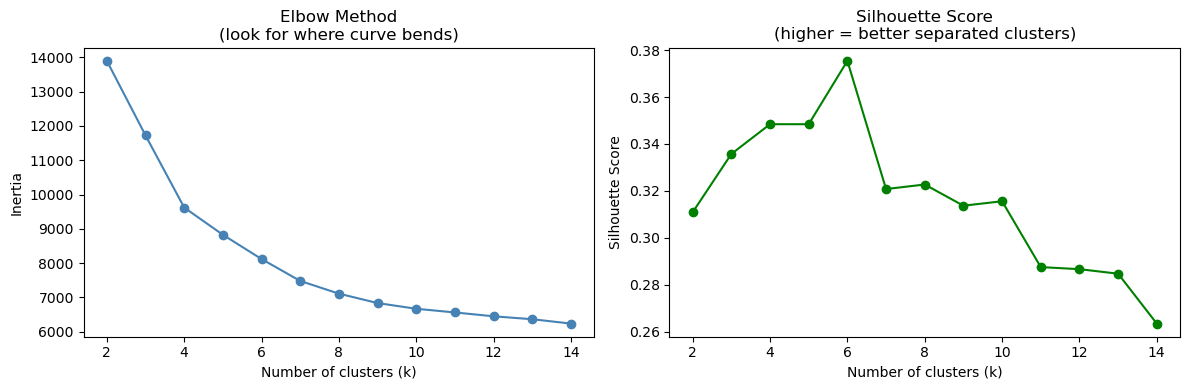

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(list(k_range), inertias, marker="o", color="steelblue")
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Inertia")
axes[0].set_title("Elbow Method\n(look for where curve bends)")

axes[1].plot(list(k_range), silhouettes, marker="o", color="green")
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score\n(higher = better separated clusters)")

plt.tight_layout()
plt.show()


In [36]:
best_k = k_range[np.argmax(silhouettes)]
print(f"\nBest k by silhouette score: {best_k}")

K      = best_k
km     = KMeans(n_clusters=K, random_state=42, n_init=10)
labels = km.fit_predict(embeddings)

cluster_df = pd.DataFrame({
    "question": questions,
    "cluster":  labels,
})

for c in range(K):
    sample = cluster_df[cluster_df["cluster"] == c]["question"].head(10).tolist()
    print(f"\nCluster {c} ({len(cluster_df[cluster_df['cluster']==c])} questions):")
    for q in sample:
        print(f"  - {q[:80]}")



Best k by silhouette score: 6

Cluster 0 (2539 questions):
  - Solana ETF approved by July 31?
  - Solana all time high before 2026?
  - Will Solana reach $210 in April?
  - Will Solana reach $190 in April?
  - Will Solana reach $170 in April?
  - Will Solana reach $150 in April?
  - Solana above $120 on April 18?
  - Solana above $150 on May 2?
  - Will Solana reach $300 in May?
  - Will Solana reach $210 in May?

Cluster 1 (14978 questions):
  - Bitcoin Up or Down in April?
  - Ethereum Up or Down in April?
  - Bitcoin Up or Down on April 8?
  - Ethereum Up or Down on April 7?
  - Ethereum Up or Down on April 8?
  - Ethereum Up or Down on April 9?
  - Bitcoin Up or Down on April 10?
  - Ethereum Up or Down on April 10?
  - Ethereum Up or Down on April 11?
  - Ethereum Up or Down on April 12?

Cluster 2 (5548 questions):
  - Trump ends Ukraine war in first 90 days?
  - Will Trump pardon Hunter Biden?
  - Trump ends taxes on tips in first 100 days?
  - Trump signs national abortion ba


PCA explained variance: 44.5%


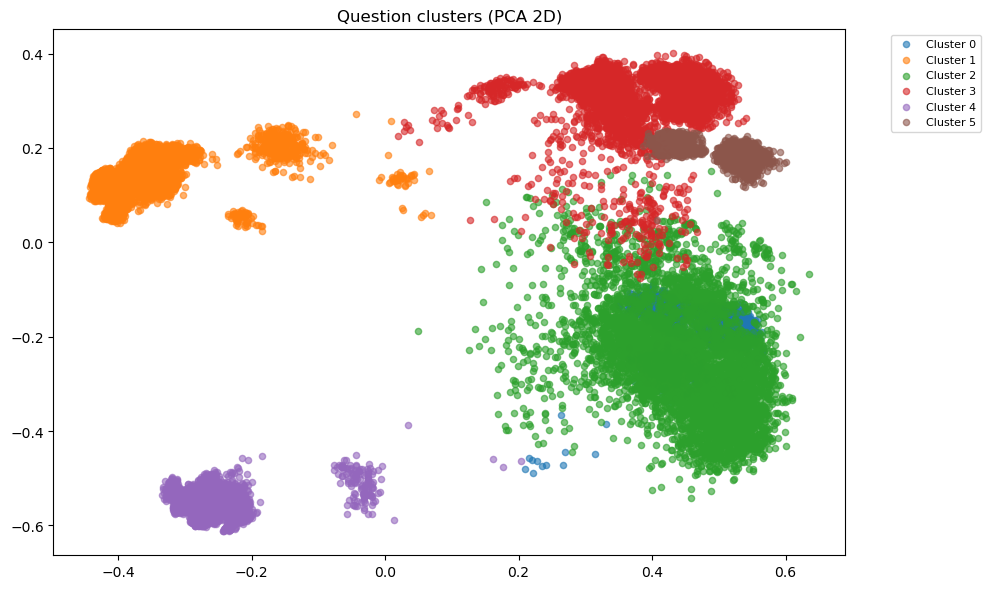

In [37]:
pca    = PCA(n_components=2)
coords = pca.fit_transform(embeddings)
print(f"\nPCA explained variance: {pca.explained_variance_ratio_.sum():.1%}")

plt.figure(figsize=(10, 6))
for c in range(K):
    mask = labels == c
    plt.scatter(coords[mask, 0], coords[mask, 1],
                label=f"Cluster {c}", alpha=0.6, s=20)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.title("Question clusters (PCA 2D)")
plt.tight_layout()
plt.savefig("cluster_plot.png", dpi=150)
plt.show()

In [38]:
daily_odds_clustered = daily_odds.merge(cluster_df, on="question", how="left")
print("\nSample with cluster labels:")
print(daily_odds_clustered[["question", "cluster"]].drop_duplicates().head(10))



Sample with cluster labels:
                                              question  cluster
0             Trump ends Ukraine war in first 90 days?        2
18                     Will Trump pardon Hunter Biden?        2
31         Trump ends taxes on tips in first 100 days?        2
55                  Trump signs national abortion ban?        2
79      Will Trump pardon Diddy in his first 100 days?        2
103  Will Trump pardon Steve Bannon in his first 10...        2
127  Will Trump pardon Edward Snowden in his first ...        2
150  Will Trump pardon Julian Assange in his first ...        2
173  Will Trump end Department of Education in firs...        2
196  Will Trump create Bitcoin reserve in first 100...        2


In [39]:
cluster_sizes = cluster_df["cluster"].value_counts().rename("cluster_size")
cluster_df    = cluster_df.merge(cluster_sizes, left_on="cluster", right_index=True)

# Sort by cluster number
cluster_df = cluster_df.sort_values("cluster").reset_index(drop=True)

cluster_df.to_csv("question_clusters.csv", index=False)

### Phase 1.2: NLP HSBSCAN

In [40]:
pca_50     = PCA(n_components=50, random_state=42)
reduced    = pca_50.fit_transform(embeddings)

In [77]:
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=1000,
    min_samples=5,
    metric="euclidean",
    cluster_selection_method="eom"
)
labels = clusterer.fit_predict(reduced)

In [78]:

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise    = (labels == -1).sum()
print(f"\nClusters found: {n_clusters}")
print(f"Noise points (no cluster): {n_noise} ({n_noise/len(questions):.1%})")



Clusters found: 13
Noise points (no cluster): 5248 (14.6%)


In [79]:
cluster_df_hdbscan = pd.DataFrame({
    "question": questions,
    "cluster":  labels,
})

In [80]:
print("\n── Sample questions per cluster ──")
for c in sorted(cluster_df_hdbscan["cluster"].unique()):
    subset = cluster_df_hdbscan[cluster_df_hdbscan["cluster"] == c]
    sample = subset["question"].head(5).tolist()
    label  = "NOISE (no group)" if c == -1 else f"Cluster {c}"
    print(f"\n{label} ({len(subset)} questions):")
    for q in sample:
        print(f"  - {q[:80]}")


── Sample questions per cluster ──

NOISE (no group) (5248 questions):
  - Trump ends Ukraine war in first 90 days?
  - Trump ends taxes on tips in first 100 days?
  - Trump signs national abortion ban?
  - Will Trump create Bitcoin reserve in first 100 days?
  - Will the GOP use 'Nuclear Option' to break filibuster?

Cluster 0 (1876 questions):
  - Will the price of XRP be above $2.79 on August 29 at 12PM ET?
  - Will the price of XRP be above $2.82 on August 29 at 4PM ET?
  - Will the price of XRP be above $2.85 on August 29 at 4PM ET?
  - Will the price of XRP be above $2.97 on August 29 at 4PM ET?
  - Will the price of XRP be above $2.79 on August 29 at 8PM ET?

Cluster 1 (4653 questions):
  - Solana all time high in April?
  - Solana Up or Down in April?
  - Solana Up or Down in May?
  - Solana Up or Down on May 8?
  - Solana Up or Down on May 9?

Cluster 2 (2538 questions):
  - Solana all time high by June 30?
  - Will Solana reach $210 in April?
  - Will Solana reach $190 in Ap

/var/folders/hn/pyg79cw15ql332wmddc7h_6c0000gn/T/ipykernel_1328/1838497388.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", n_clusters)


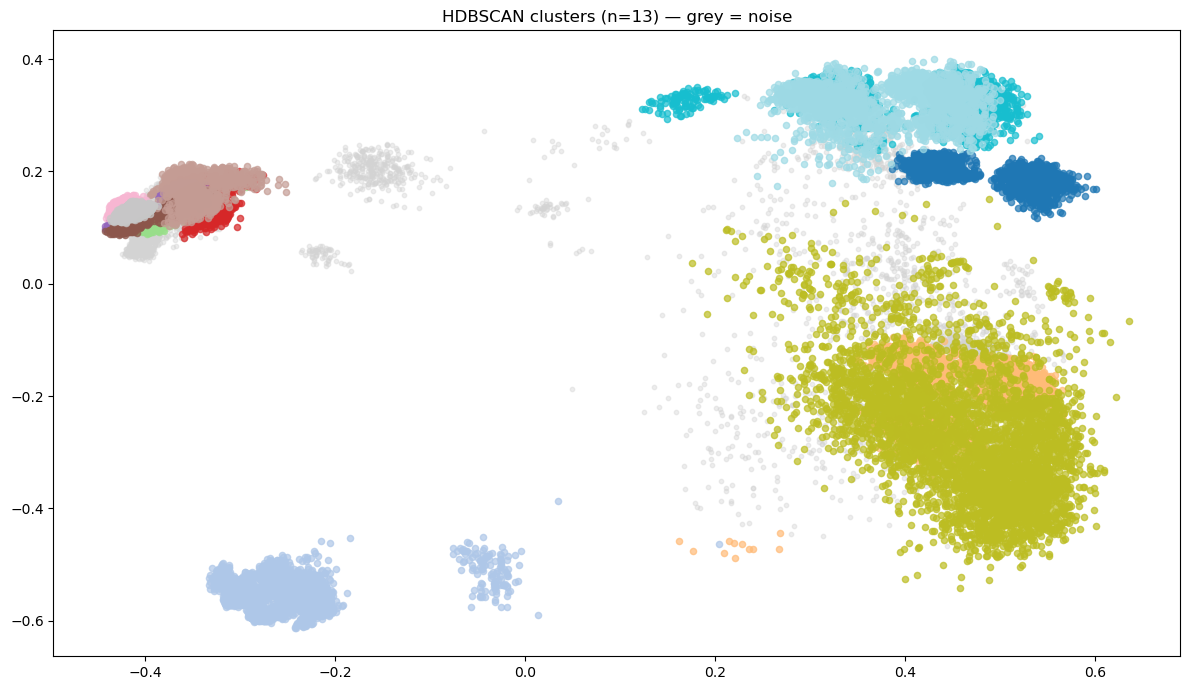

In [81]:

plt.figure(figsize=(12, 7))
# Plot noise points first in grey
noise_mask = labels == -1
plt.scatter(coords[noise_mask, 0], coords[noise_mask, 1],
            c="lightgrey", s=10, alpha=0.4, label="Noise")

# Plot each cluster
cmap = plt.cm.get_cmap("tab20", n_clusters)
for i, c in enumerate(sorted(set(labels) - {-1})):
    mask = labels == c
    plt.scatter(coords[mask, 0], coords[mask, 1],
                color=cmap(i), s=20, alpha=0.7, label=f"C{c}")

# plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=7, ncol=2)
plt.title(f"HDBSCAN clusters (n={n_clusters}) — grey = noise")
plt.tight_layout()
plt.savefig("hdbscan_clusters.png", dpi=150)
plt.show()

In [82]:
cluster_sizes = cluster_df_hdbscan["cluster"].value_counts().rename("cluster_size")
cluster_df_hdbscan    = cluster_df_hdbscan.merge(cluster_sizes, left_on="cluster", right_index=True)
cluster_df_hdbscan    = cluster_df_hdbscan.sort_values("cluster").reset_index(drop=True)

In [83]:

cluster_df_hdbscan.to_csv("question_clusters_hdbscan.csv", index=False)
print("\nSaved to question_clusters_hdbscan.csv")
print("\nCluster summary:")
print(cluster_df_hdbscan.groupby("cluster")["question"].count().to_string())


Saved to question_clusters_hdbscan.csv

Cluster summary:
cluster
-1     5248
 0     1876
 1     4653
 2     2538
 3     1404
 4     1160
 5     2195
 6     2106
 7     1254
 8     1779
 9     1690
 10    4396
 11    2863
 12    2881


Exception ignored in: <function ResourceTracker.__del__ at 0x102a31bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x108f45bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1056f1bc0>
Traceback (most recent call last

### Phase 1.3: LLM

In [84]:
from transformers import pipeline
import torch

In [85]:
TOPIC_DIRECTIONS = {
    "Bitcoin price target":                        +1,  # BTC price up = good
    "Ethereum price target":                       +1,  # ETH up = good for crypto
    "Solana price target":                         +1,  # SOL up = good for crypto
    "gold or dollar strength":                     +1,  # risk-on assets up = good
    "Trump policy and executive order":            +1,  # trump pro-crypto stance
    "MicroStrategy or corporate Bitcoin holding":  +1,  # institutional BTC = good
    "crypto regulation and SEC approval":          +1,  # positive regulation = good
    "Federal Reserve interest rate cut":           +1,  # rate cuts = good for BTC
    "tariff and trade war escalation":             -1,  # tariffs = bad for BTC
    "Federal Reserve interest rate hike":          -1,  # rate hikes = bad for BTC
    "macroeconomics GDP recession unemployment":   -1,  # recession = bad for BTC
    "crypto ban or negative regulation":           -1,  # ban = bad for BTC
    "global politics and foreign elections":        0,  # mixed signal
    "sports and entertainment":                     0,  # no BTC impact
    "other":                                        0,  # neutral
}
TOPICS = list(TOPIC_DIRECTIONS.keys())

In [86]:
print("\nLoading classifier (downloads on first run)...")
device    = 0 if torch.cuda.is_available() else -1  # use GPU if available
classifier = pipeline(
    "zero-shot-classification",
    model="facebook/bart-large-mnli",
    device=device
)
print("Model loaded!")


Loading classifier (downloads on first run)...


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Model loaded!


In [87]:
BATCH_SIZE = 32
all_results = []

for i in range(0, len(questions), BATCH_SIZE):
    batch = questions[i:i + BATCH_SIZE]
    print(f"Classifying {i+1} to {min(i+BATCH_SIZE, len(questions))} of {len(questions)}...")

    outputs = classifier(batch, TOPICS, multi_label=False)

    # outputs is a list when batch > 1, dict when batch == 1
    if isinstance(outputs, dict):
        outputs = [outputs]

    for q, out in zip(batch, outputs):
        best_topic = out["labels"][0]
        best_score = out["scores"][0]
        all_results.append({
            "question":      q,
            "topic":         best_topic,
            "confidence":    round(best_score, 3),
            "btc_direction": TOPIC_DIRECTIONS[best_topic],
        })

Classifying 1 to 32 of 36043...
Classifying 33 to 64 of 36043...
Classifying 65 to 96 of 36043...
Classifying 97 to 128 of 36043...
Classifying 129 to 160 of 36043...
Classifying 161 to 192 of 36043...
Classifying 193 to 224 of 36043...
Classifying 225 to 256 of 36043...
Classifying 257 to 288 of 36043...
Classifying 289 to 320 of 36043...
Classifying 321 to 352 of 36043...
Classifying 353 to 384 of 36043...
Classifying 385 to 416 of 36043...
Classifying 417 to 448 of 36043...
Classifying 449 to 480 of 36043...
Classifying 481 to 512 of 36043...
Classifying 513 to 544 of 36043...
Classifying 545 to 576 of 36043...
Classifying 577 to 608 of 36043...
Classifying 609 to 640 of 36043...
Classifying 641 to 672 of 36043...
Classifying 673 to 704 of 36043...
Classifying 705 to 736 of 36043...
Classifying 737 to 768 of 36043...
Classifying 769 to 800 of 36043...
Classifying 801 to 832 of 36043...
Classifying 833 to 864 of 36043...
Classifying 865 to 896 of 36043...
Classifying 897 to 928 of 36

In [88]:
classification_df = pd.DataFrame(all_results)

print("\nTopic distribution:")
print(classification_df["topic"].value_counts())

print("\nBTC direction distribution:")
print(classification_df["btc_direction"].value_counts())

print("\nLow confidence classifications (< 0.5):")
low_conf = classification_df[classification_df["confidence"] < 0.5]
print(f"  {len(low_conf)} questions ({len(low_conf)/len(classification_df):.1%})")

classification_df.to_csv("question_classifications.csv", index=False)
print("\nSaved to question_classifications.csv")



Topic distribution:
topic
Bitcoin price target                          10765
Ethereum price target                         10505
other                                          9751
Solana price target                            4309
Trump policy and executive order                175
global politics and foreign elections           119
sports and entertainment                        118
Federal Reserve interest rate cut                90
crypto ban or negative regulation                71
Federal Reserve interest rate hike               63
MicroStrategy or corporate Bitcoin holding       36
gold or dollar strength                          27
tariff and trade war escalation                  12
crypto regulation and SEC approval                1
macroeconomics GDP recession unemployment         1
Name: count, dtype: int64

BTC direction distribution:
btc_direction
 1    25908
 0     9988
-1      147
Name: count, dtype: int64

Low confidence classifications (< 0.5):
  11427 questions (31